<h3  style = "color: skyblue" >Importing Libraries<h3>

In [104]:
import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, train_test_split

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


<h3  style = "color: skyblue" >Data Ingestion and Loading<h3>

In [105]:
df = pd.read_excel("../data/premiums_young.xlsx")
print("Few observations:")
df.head()

Few observations:


,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


<h3 style = "color:skyblue" >Data Overview</h3>

In [106]:
print("Number of rows and columns:", df.shape)
print("Number of duplicated observations:", df.duplicated().sum())
print("====" * 10)
print("Data Types of each fields:\n")
print(df.dtypes)
print("====" * 10)
print("Number of missing values per columns:")
df.isna().sum()

Number of rows and columns: (20096, 13)
Number of duplicated observations: 0
Data Types of each fields:

Age                       int64
Gender                   object
Region                   object
Marital_status           object
Number Of Dependants      int64
BMI_Category             object
Smoking_Status           object
Employment_Status        object
Income_Level             object
Income_Lakhs              int64
Medical History          object
Insurance_Plan           object
Annual_Premium_Amount     int64
dtype: object
Number of missing values per columns:


Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           2
Employment_Status        1
Income_Level             4
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
dtype: int64

<h3 style = "color:skyblue" >Sanity Cleaning</h3>

In [107]:
#making field names consistent
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [108]:
#lower + snakecase
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

In [109]:
#since the number of missng value is small we can delete it
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

<h3 style = "color:skyblue" >Exploratory Data Analysis</h3>

#### 1. Summary Stats

In [110]:
print("Quick Summary Statistics:")
df.describe()

Quick Summary Statistics:


,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267
std,2.294052,0.940713,23.420493,2749.906347
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


Problems -
* certainly an outliers in the `age` field.
* number of dependants cannot be `negative`
* maybe an outlier in income_lakhs

In [111]:
# solve for the number of dependants
df['number_of_dependants'].unique()

array([ 0,  2,  1,  3, -3, -1], dtype=int64)

In [112]:
# there are 72 observations that is less that has negative values
# there may be some error in data entry and maybe it is +ve values
# talked to business and they said to replace with +ve values 
df[df['number_of_dependants'] < 0].shape

(22, 13)

In [113]:
df['number_of_dependants'] = df['number_of_dependants'].abs()
df['number_of_dependants'].unique()

array([0, 2, 1, 3], dtype=int64)

#### 2. Univariate Analysis - numeric 

In [114]:
numeric_columns = df.select_dtypes('number').columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

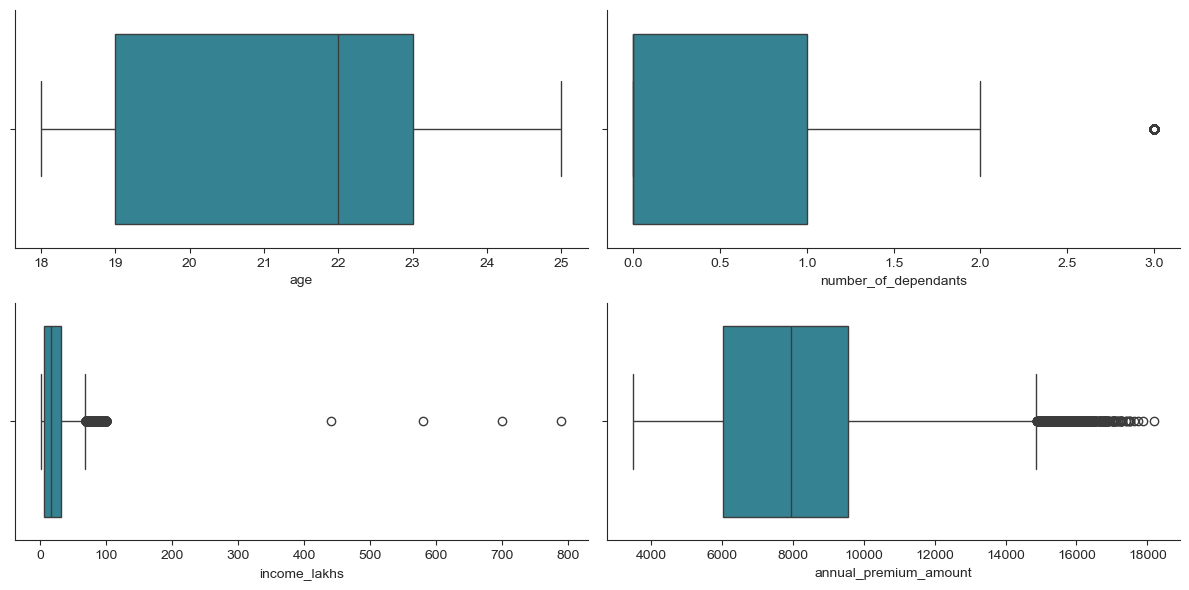

In [115]:
#solve for outliers
#numeric
plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.boxplot(x=df[col], color="#258DA2")
    
    
plt.tight_layout()
sns.despine()
plt.show()

In [116]:
# Outlier Treatment for age column 
# We do not need Statistical techniques for removing the outlier in age
# Simply use a threshold value

df[df['age'] > 100].head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount


In [117]:
df[df['age'] > 100]['age'].unique()

array([], dtype=int64)

In [118]:
#do reverse condition for filtering the age
#create a copy
data = df[df['age'] <= 100].copy()
data['age'].describe()

count    20090.000000
mean        21.494375
std          2.294052
min         18.000000
25%         19.000000
50%         22.000000
75%         23.000000
max         25.000000
Name: age, dtype: float64

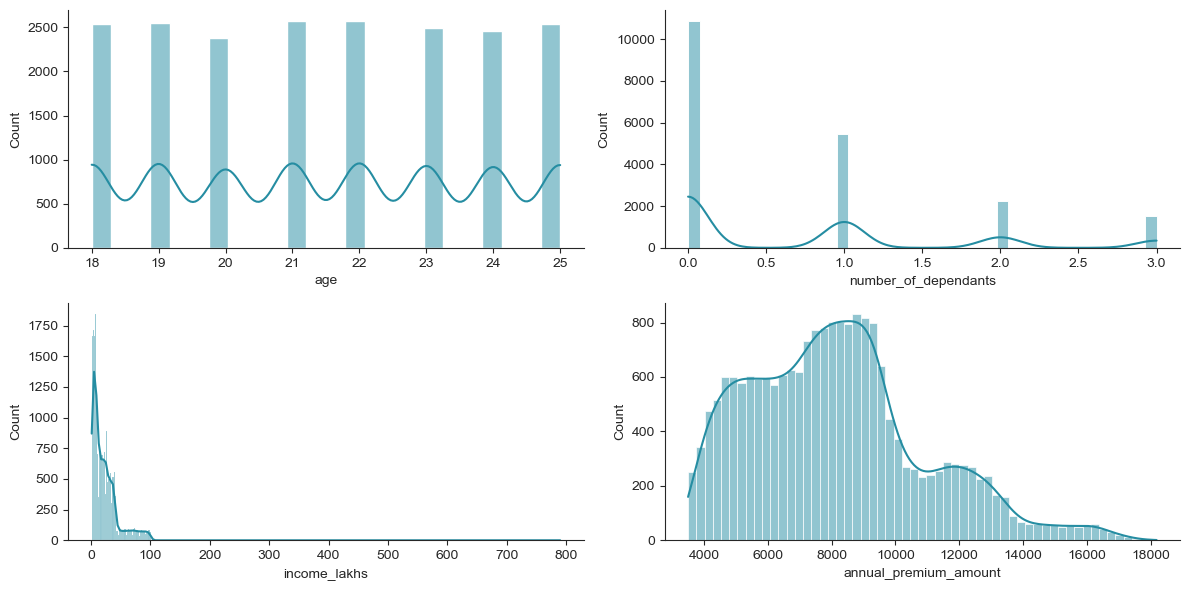

In [119]:
#distribution plot with outliers

plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(x=data[col], color="#258DA2", kde= True)
    
    
plt.tight_layout()
sns.despine()
plt.show()



In [120]:
# Outlier Treatment for income_lakhs column
# Using an IQR method to solve outlier problem

data['income_lakhs'].describe()


count    20090.000000
mean        22.510851
std         23.420493
min          1.000000
25%          6.000000
50%         16.000000
75%         31.000000
max        790.000000
Name: income_lakhs, dtype: float64

In [121]:
#quantile
Q1, Q3 = data['income_lakhs'].quantile([0.25, 0.75])
Q1, Q3

(6.0, 31.0)

In [122]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return lower_bound, upper_bound


In [123]:
get_iqr_bounds(data['income_lakhs'])

(-31.5, 68.5)

- 67 LPA is okay but can I use it as my upperbound
- Try bunch of other methods

In [124]:
data['income_lakhs'].quantile(0.999)

100.0

In [125]:
qunatile_threshhold = data['income_lakhs'].quantile(0.999)
qunatile_threshhold

100.0

1 Cr income is okay when we use upper bound as 0.999

In [126]:
print("Observations that has income more than threshold i.e 1 Cr: ")
data[data['income_lakhs'] > qunatile_threshhold]


Observations that has income more than threshold i.e 1 Cr: 


,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
1677,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,440,No Disease,Silver,10636
4311,20,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,580,Thyroid,Silver,12888
4661,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424
6251,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586


In [127]:
print(f"Number of such observations: {data[data['income_lakhs'] > qunatile_threshhold].shape}")

Number of such observations: (4, 13)


In [128]:
# drop those columns that has income > 1 Cr
# do reverse condition
data = data[data['income_lakhs'] <= qunatile_threshhold]
data["income_lakhs"].describe()

count    20086.000000
mean        22.390371
std         21.732062
min          1.000000
25%          6.000000
50%         16.000000
75%         31.000000
max        100.000000
Name: income_lakhs, dtype: float64

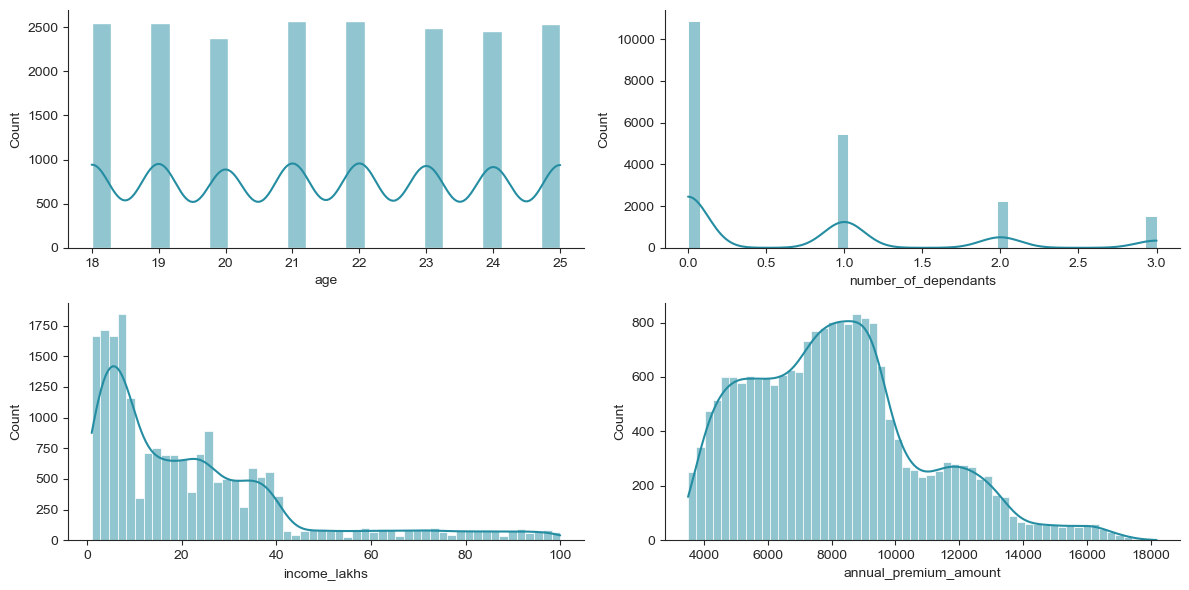

In [129]:
#distribution plot after removal of outliers

plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(x=data[col], color="#258DA2", kde= True)
    
    
plt.tight_layout()
sns.despine()
plt.show()

#### 2. Bivariate Analysis - numeric


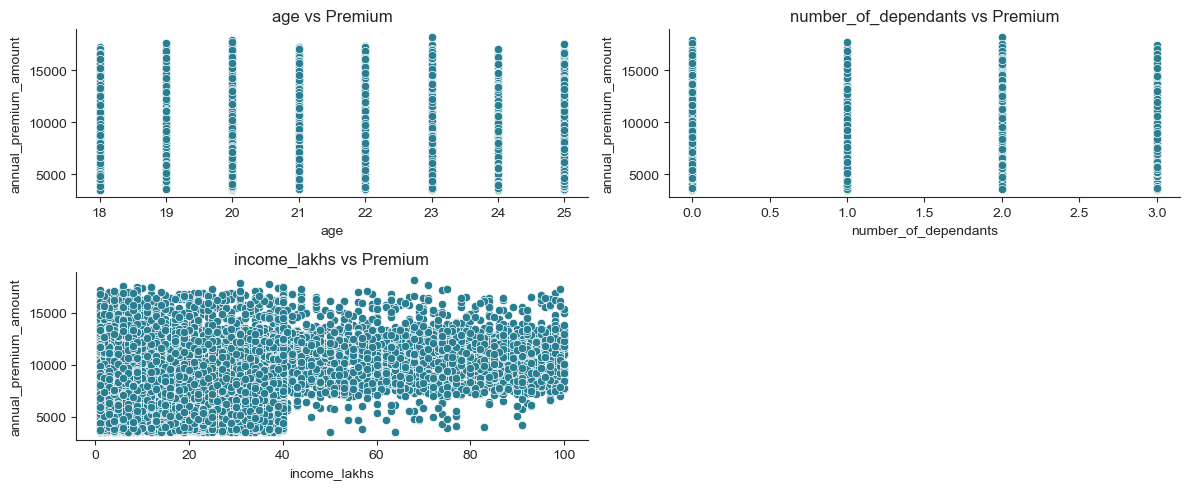

In [130]:

# Scatter plots: numeric vs target
scatter_cols = numeric_columns.drop('annual_premium_amount')

plt.figure(figsize=(12, 5))

ncols = 2
nrows = math.ceil(len(scatter_cols) / ncols)

for i, col in enumerate(scatter_cols, start=1):
    plt.subplot(nrows, ncols, i)
    sns.scatterplot(data=data, x=col, y='annual_premium_amount', color="#297F91")
    plt.title(f"{col} vs Premium")

plt.tight_layout()
sns.despine()
plt.show()


#### Categorical Columns

In [131]:
categorical_cols = data.select_dtypes('object').columns
categorical_cols

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [132]:
for col in categorical_cols:
    print(col, ":", data[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


There is clearly some data inconsistency in smoking status


In [133]:
#make value consistent
data['smoking_status'] = data['smoking_status'].replace({
    'Smoking=0' : 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Not Smoking': 'No Smoking'
})

data['smoking_status'].unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

#### Summary Stats

In [134]:
data.select_dtypes('object').describe().T

,count,unique,top,freq
gender,20086,2,Male,11055
region,20086,4,Southeast,6969
marital_status,20086,2,Unmarried,18075
bmi_category,20086,4,Normal,11599
smoking_status,20086,3,No Smoking,13860
employment_status,20086,3,Freelancer,10043
income_level,20086,4,<10L,7721
medical_history,20086,9,No Disease,16873
insurance_plan,20086,3,Bronze,14177


####  Univariate Analysis - categorical

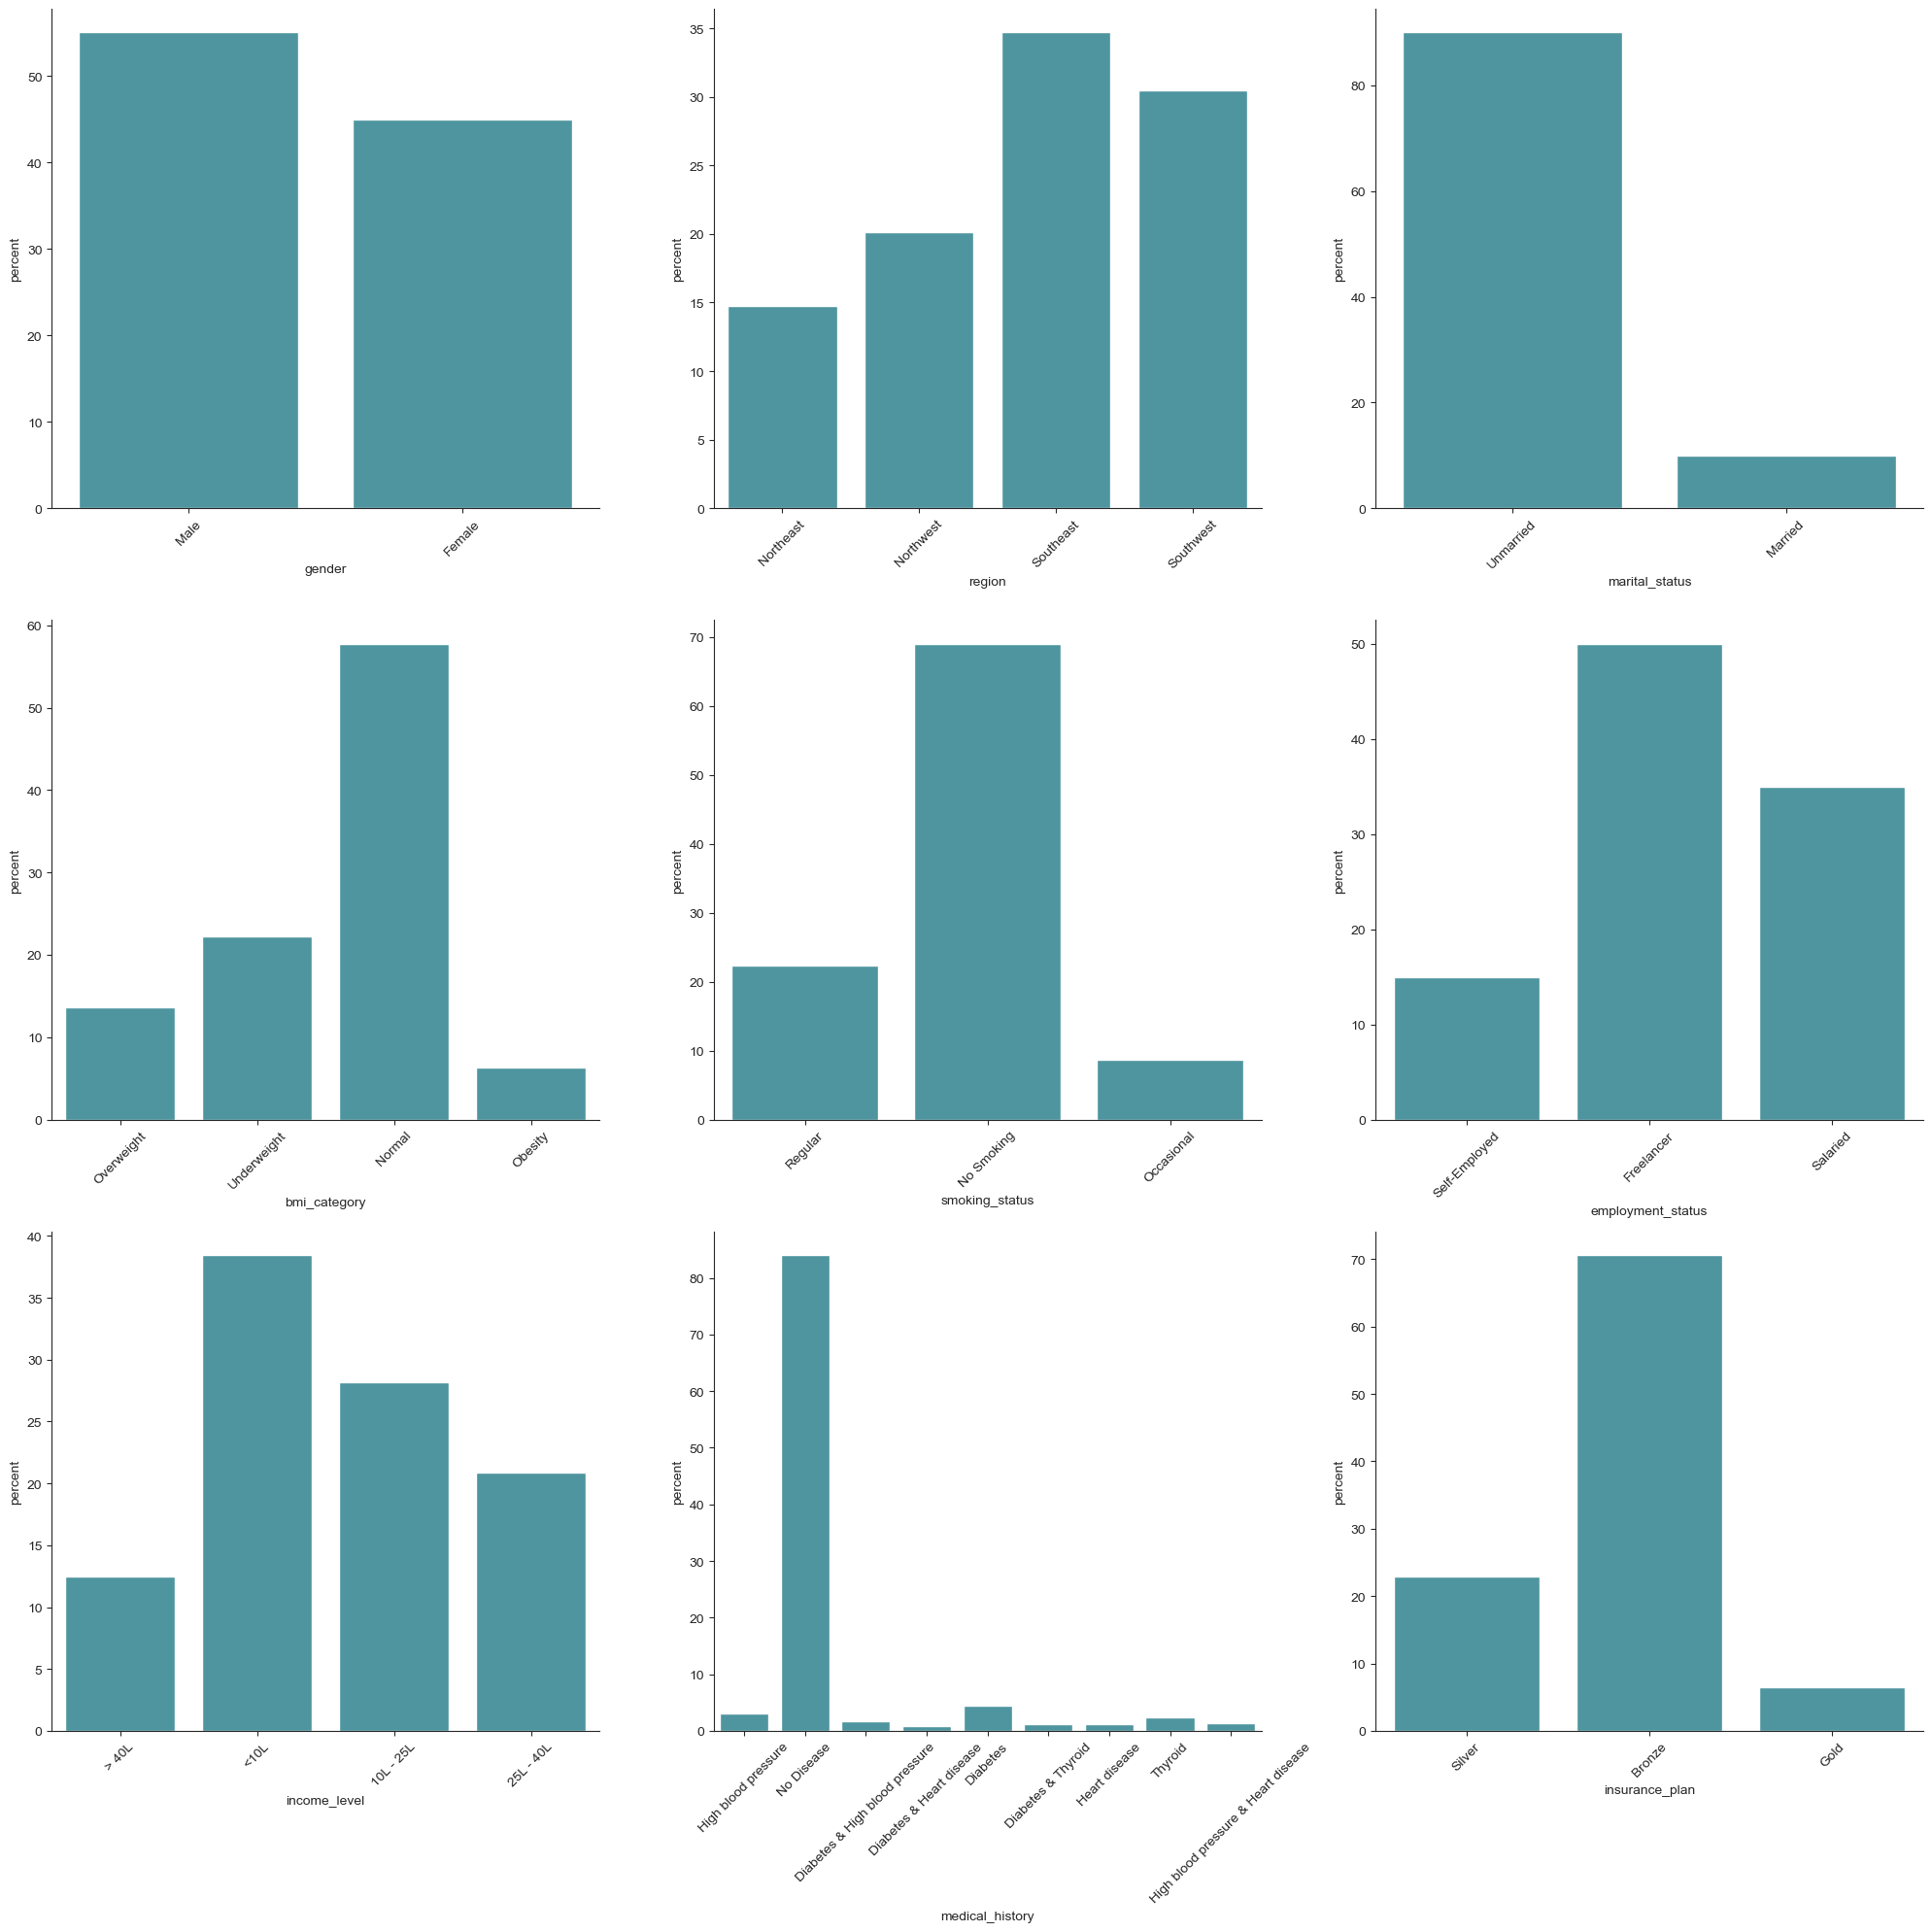

In [135]:
plt.figure(figsize=(20, 20))

ncols = 3
nrows = math.ceil(len(categorical_cols) / ncols)

for i, col in enumerate(categorical_cols, start=1):
    plt.subplot(nrows, ncols, i)
    sns.countplot(data=data, x=col, color="#409FAD", stat='percent')
    plt.xticks(rotation=45)

plt.tight_layout()
sns.despine()
plt.show()


#### Bivariate Analysis - categorical


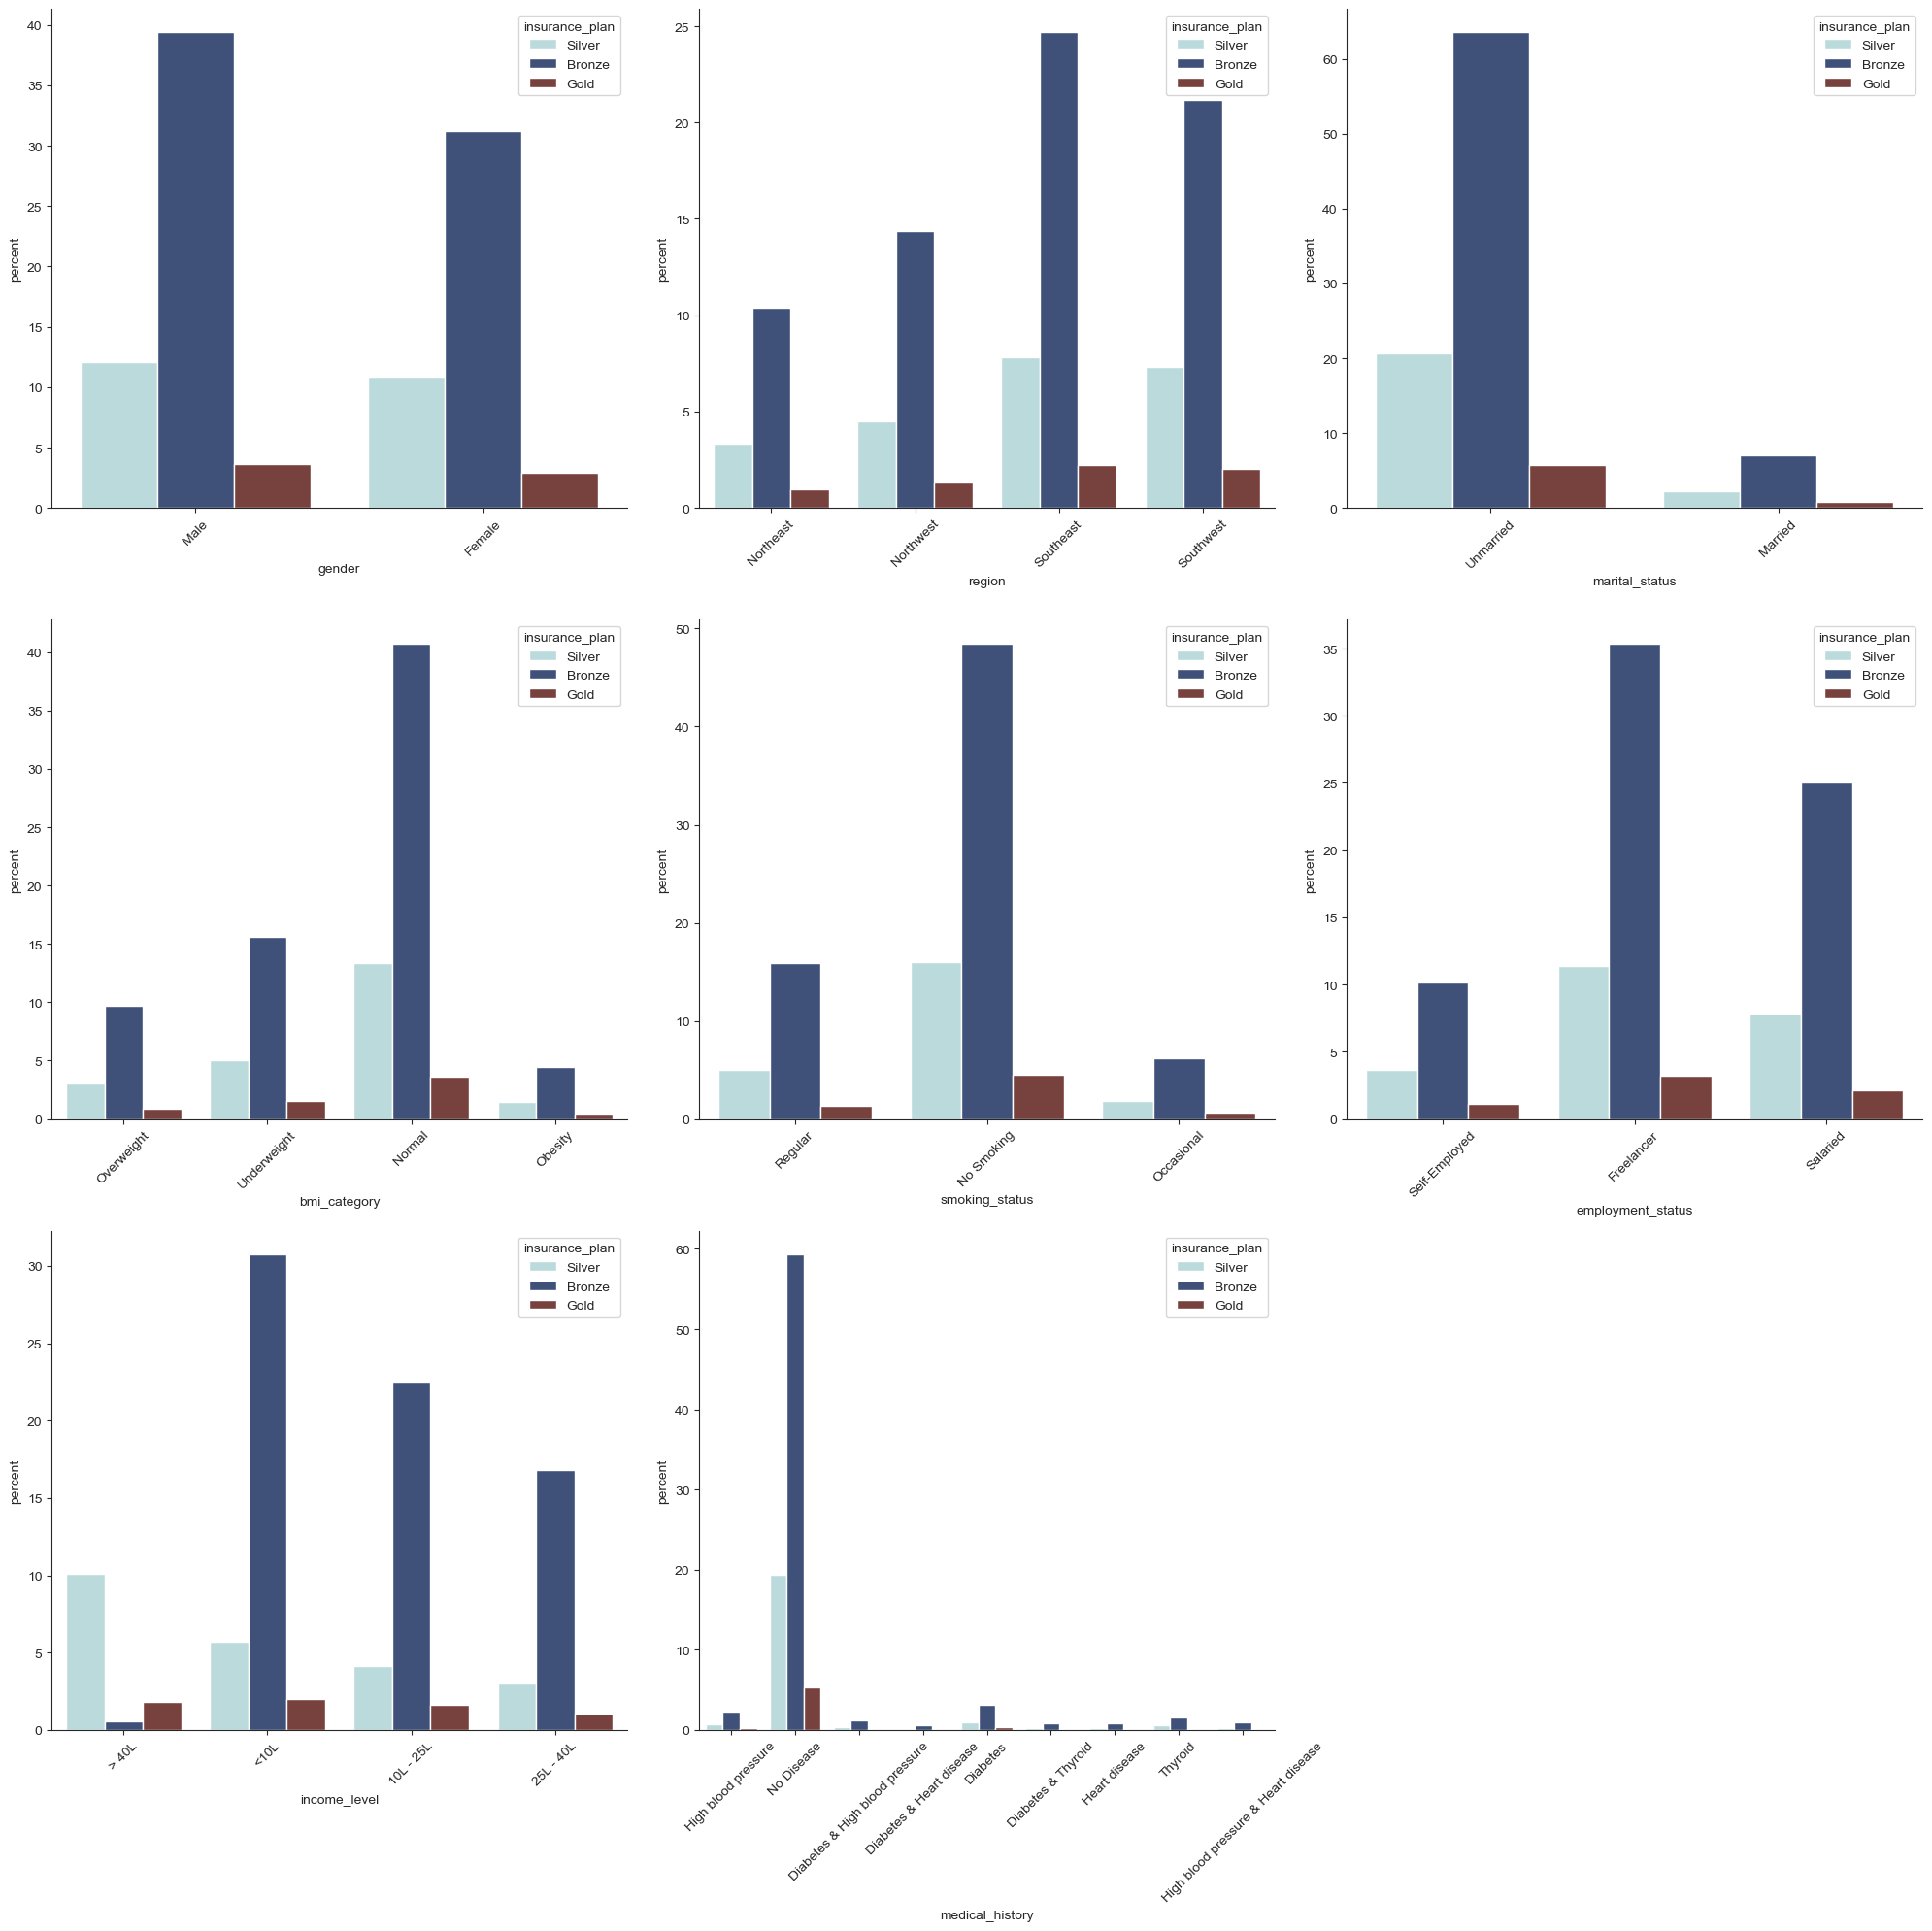

In [136]:
plt.figure(figsize=(20, 20))
sns.set_style('ticks')

ncols = 3
nrows = math.ceil(len(categorical_cols) / ncols)
Palette = ["#B5DFE2", "#354E83", "#803835"]

for i, col in enumerate(categorical_cols.drop('insurance_plan'), start=1):
    plt.subplot(nrows, ncols, i)
    sns.countplot(data=data, x=col, color="#409FAD", stat='percent', hue= data['insurance_plan'], palette= Palette)
    plt.xticks(rotation=45)

plt.tight_layout()
sns.despine()
plt.show()


<h3  style = "color: skyblue">Feature Engineering</h3>

1. Feature Construction
2. Feature Transformation
3. Feature Selection

#### 1. Feature Construction

In [137]:
data.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


In [138]:
data['medical_history'].unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [139]:
# Define the risk scores for each condition

risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}


In [140]:
#sep each diseases, make dataframe, and make each case lower
data[['disease1', 'disease2']] = data['medical_history'].str.split("&", expand= True).apply( lambda x:x.str.lower().str.strip())

data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
15426,19,Female,Southeast,Unmarried,2,Overweight,Regular,Freelancer,<10L,7,No Disease,Bronze,7474,no disease,None
4791,20,Female,Southwest,Married,2,Underweight,No Smoking,Freelancer,<10L,1,High blood pressure,Bronze,6230,high blood pressure,None
13767,19,Female,Northeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,19,No Disease,Bronze,9001,no disease,None
7667,20,Male,Northwest,Unmarried,0,Normal,Regular,Self-Employed,> 40L,44,No Disease,Silver,12344,no disease,None
19780,24,Male,Southwest,Unmarried,0,Underweight,Occasional,Salaried,<10L,8,No Disease,Bronze,5037,no disease,None


In [141]:
data['disease1'] = data['disease1'].fillna('none')
data['disease2'] = data['disease1'].fillna('none')

data['total_risk_scores'] = 0

In [142]:
data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores
19377,18,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,<10L,1,No Disease,Silver,9796,no disease,no disease,0
3153,24,Male,Southwest,Married,3,Overweight,No Smoking,Freelancer,<10L,8,No Disease,Bronze,8621,no disease,no disease,0
8670,18,Male,Southwest,Unmarried,1,Normal,No Smoking,Freelancer,25L - 40L,31,No Disease,Bronze,7438,no disease,no disease,0
13711,25,Female,Southwest,Married,3,Normal,Regular,Salaried,<10L,1,Diabetes & Thyroid,Bronze,6302,diabetes,diabetes,0
9255,24,Female,Southeast,Unmarried,0,Normal,Regular,Self-Employed,> 40L,95,No Disease,Silver,10821,no disease,no disease,0


In [143]:
for disease in ['disease1', 'disease2']:
    data['total_risk_scores'] += data[disease].map(risk_scores)

data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores
9216,18,Male,Northwest,Unmarried,0,Normal,No Smoking,Freelancer,<10L,8,No Disease,Bronze,4594,no disease,no disease,0
18041,20,Male,Southeast,Unmarried,2,Normal,Regular,Salaried,10L - 25L,19,No Disease,Bronze,6272,no disease,no disease,0
19816,23,Male,Northeast,Unmarried,0,Underweight,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,4683,no disease,no disease,0
7755,20,Male,Northwest,Unmarried,1,Normal,No Smoking,Salaried,10L - 25L,17,No Disease,Bronze,6121,no disease,no disease,0
8524,25,Female,Northwest,Unmarried,0,Normal,No Smoking,Freelancer,<10L,2,No Disease,Bronze,5827,no disease,no disease,0


#### 2. Feature Transformation

1. Label Encoding : `Ordinal Data`
2. One Hot Encoding: `Nominal Data`
3. Feature Scaling

Label Encoding for Ordinal Data

In [144]:
#For insurnace plan
#can do label encoding since it is ordinal data
data['insurance_plan'] = data['insurance_plan'].map({
    'Bronze': 1,
    'Silver': 2,
    'Gold': 3
})

data['insurance_plan'].unique()

array([2, 1, 3], dtype=int64)

In [145]:
#similarly for income_level we can do Label encoding
data['income_level'].unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [146]:
data['income_level'] = data['income_level'].map({
    '<10L': 1,
    '10L - 25L': 2,
    '25L - 40L': 3,
    '> 40L': 4
})

data['income_level'].unique()

array([4, 1, 2, 3], dtype=int64)

One Hot Encoding for Nominal Data

In [147]:
data.select_dtypes('object').columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'medical_history', 'disease1', 'disease2'],
      dtype='object')

In [148]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']

data_v1 = pd.get_dummies(data=data, columns= nominal_cols, drop_first= True, dtype='int')
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,high blood pressure,high blood pressure,12,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,no disease,no disease,0,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,no disease,no disease,0,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,no disease,no disease,0,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,no disease,no disease,0,...,1,0,1,0,1,0,0,0,0,0


Feature Scaling

In [149]:
#Use MinMaxScaler
cols_to_scale = ['age', 'number_of_dependants', 'income_level',	'income_lakhs',	'insurance_plan', 'total_risk_scores']

scaler = MinMaxScaler()
data_v1[cols_to_scale] = scaler.fit_transform(data_v1[cols_to_scale])
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,High blood pressure,0.5,13365,high blood pressure,high blood pressure,0.75,...,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,No Disease,0.5,11050,no disease,no disease,0.00,...,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,No Disease,0.5,11857,no disease,no disease,0.00,...,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,No Disease,0.0,5684,no disease,no disease,0.00,...,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,No Disease,0.0,5712,no disease,no disease,0.00,...,1,0,1,0,1,0,0,0,0,0


#### 3. Feature Selection

1. Business understanding

2. Statistical Techniques:
      - Filtered-based : correlation matrix
      - Embedded method

In [150]:
data_v1.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'disease1', 'disease2', 'total_risk_scores', 'gender_Male',
       'region_Northwest', 'region_Southeast', 'region_Southwest',
       'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [151]:
#Dropping some columns that is not necessary
data_v1 = data_v1.drop(columns=['medical_history', 'disease1', 'disease2'])
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,0.5,13365,0.75,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,0.5,11050,0.00,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,0.5,11857,0.00,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,0.0,5684,0.00,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,0.0,5712,0.00,1,0,1,0,1,0,1,0,0,0,0,0


#### 1. Filtered-based method

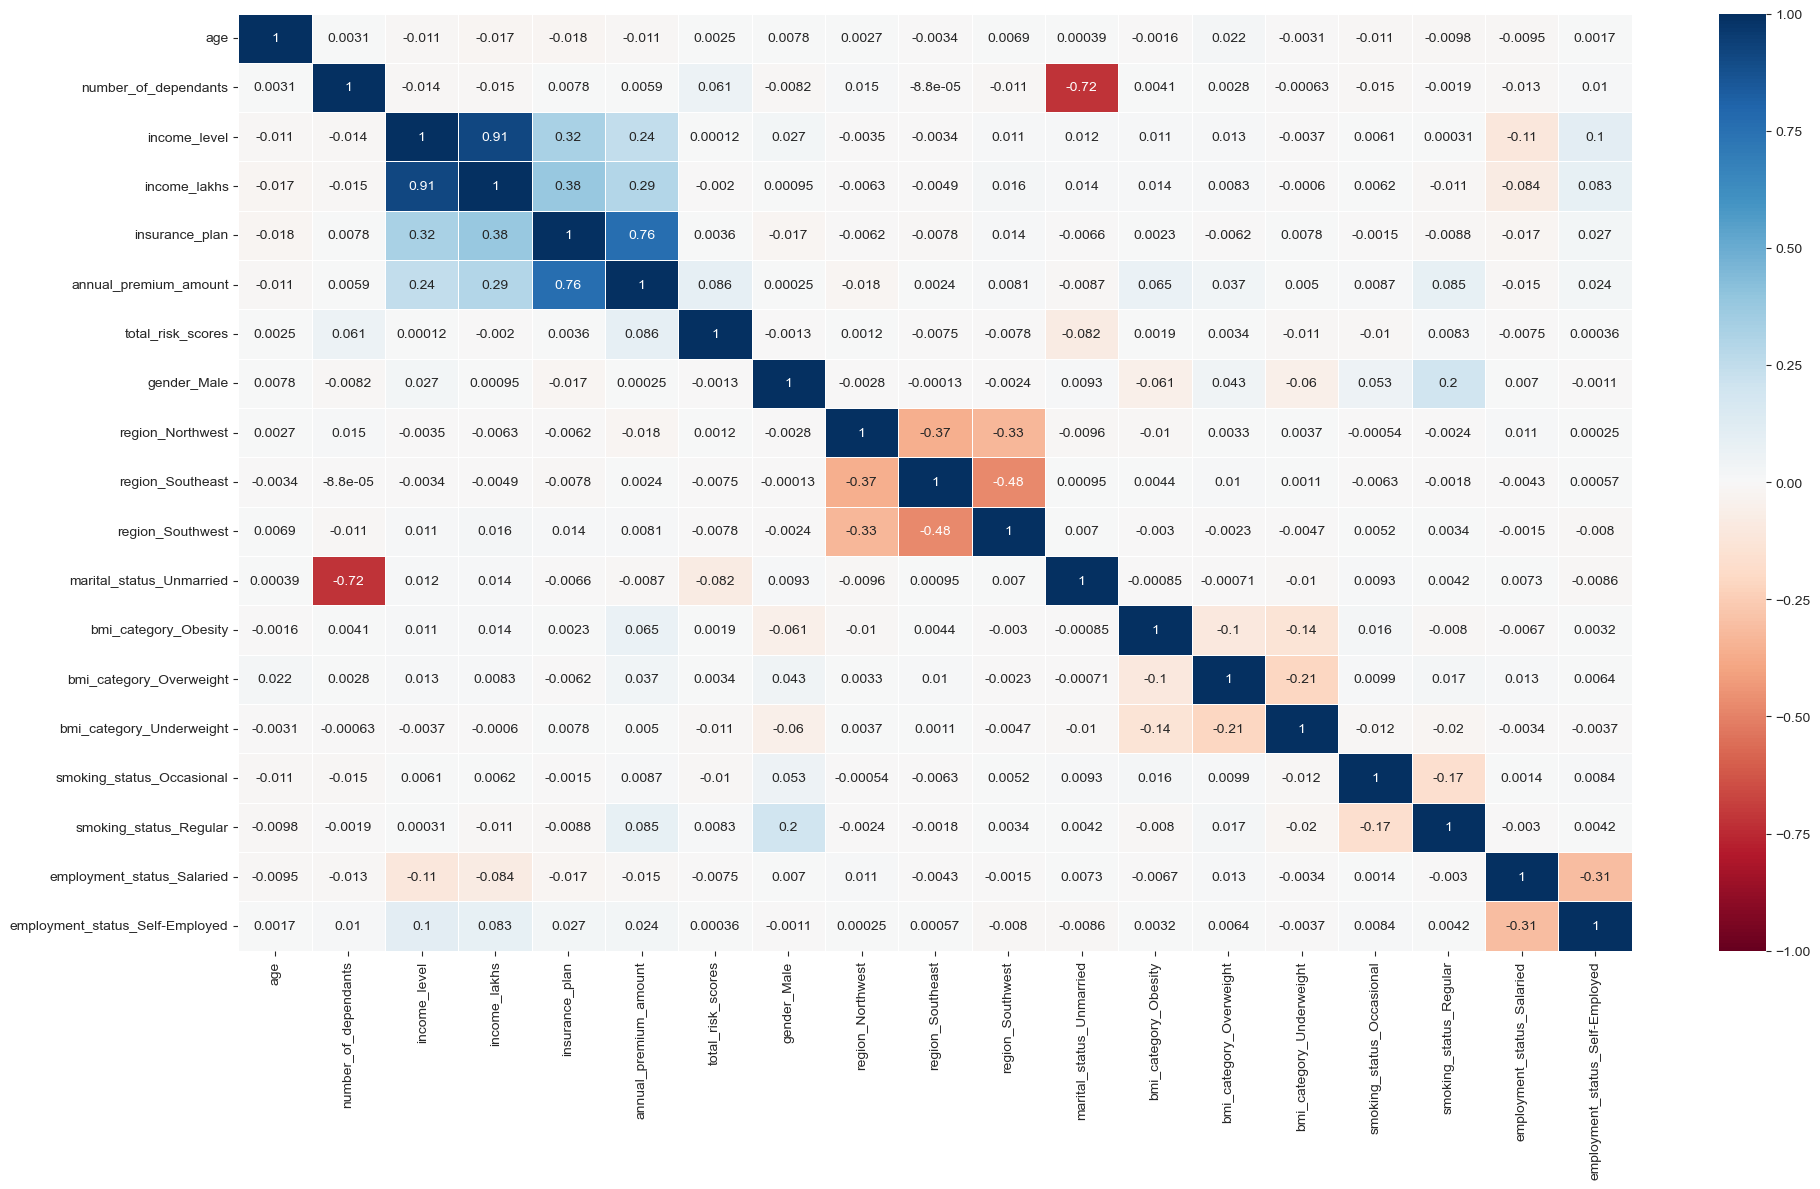

In [152]:
#Correlation matrix
cm = data_v1.corr()

plt.figure(figsize=(20,12))
sns.set_style('ticks')

sns.heatmap(cm, annot= True, vmin= -1, vmax=1, cmap="RdBu", linewidths=0.7)
plt.tight_layout()
plt.show()

Strong multicollinearity: (income_level, income_lakhs) and (insurance_plan, annual_premium_amount) are highly correlated.

Marital status effects: Unmarried is strongly negatively related to age, dependants, and premium.

##### Calculate VIF for Multicolinearity

In [153]:
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,0.5,13365,0.75,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,0.5,11050,0.00,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,0.5,11857,0.00,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,0.0,5684,0.00,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,0.0,5712,0.00,1,0,1,0,1,0,1,0,0,0,0,0


In [154]:
X = data_v1.drop(columns=['annual_premium_amount'])
y = data_v1['annual_premium_amount']

In [155]:
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,0.5,0.75,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,0.5,0.00,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,0.5,0.00,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,0.0,0.00,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,0.0,0.00,1,0,1,0,1,0,1,0,0,0,0,0


In [156]:
y[:5]

0    13365
1    11050
2    11857
3     5684
4     5712
Name: annual_premium_amount, dtype: int64

In [157]:
def calculate_vif(X):
    vif_df = pd.DataFrame()
    vif_df['Columns'] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range (X.shape[1])] 

    return vif_df

In [158]:
calculate_vif(X)

,Columns,VIF
0,age,3.143620
1,number_of_dependants,1.865538
2,income_level,11.929351
3,income_lakhs,11.874230
4,insurance_plan,1.592910
5,total_risk_scores,1.181212
6,gender_Male,2.310090
7,region_Northwest,2.148154
8,region_Southeast,2.970806
9,region_Southwest,2.730848


In [159]:
#we will drop income_lakhs due to high VIF value
X = X.drop(columns=['income_level'])

In [160]:
#recalculating VIF

calculate_vif(X)

,Columns,VIF
0,age,3.142289
1,number_of_dependants,1.862948
2,income_lakhs,2.292165
3,insurance_plan,1.587807
4,total_risk_scores,1.181098
5,gender_Male,2.299933
6,region_Northwest,2.147230
7,region_Southeast,2.969623
8,region_Southwest,2.730166
9,marital_status_Unmarried,7.292754


In [161]:
X.shape

(20086, 17)

<h3  style = "color: skyblue" >Modeling<h3>


Hold-out approach

In [162]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train:", X_train.shape)
print("y train:", y_train.shape)
print("y train:", X_test.shape)
print("y test:", y_test.shape)

x train: (14060, 17)
y train: (14060,)
y train: (6026, 17)
y test: (6026,)


Base Model: Linear Regression

In [163]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [164]:
y_pred = model_lr.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 3014678.820260159
RMSE: 1736.2830472766125
R2 Score: 0.6035742541343041


Cross validation appraoch

In [165]:
kfold = KFold(n_splits=5, shuffle= True, random_state=42)

scores = cross_val_score(estimator = model_lr, X= X, y= y, cv=kfold, scoring='r2')

print("R2 scores for each folds:", scores)
print("Mean R2 score across all folds:", np.mean(scores))

R2 scores for each folds: [0.59700027 0.60651205 0.60485883 0.59477288 0.60272215]
Mean R2 score across all folds: 0.6011732358848294


In [166]:
model_lr.intercept_

6596.899786686166

In [167]:
model_lr.coef_

array([ 5.76789701e+01, -1.43073921e+02, -4.55621792e+01,  7.00241957e+03,
        8.67460412e+02,  9.14618923e+00, -1.12914961e+02, -3.67104450e+01,
       -6.51995938e+01, -4.07337701e+01,  7.90819536e+02,  4.35580330e+02,
        1.69213421e+02,  2.43863140e+02,  6.18366627e+02, -1.30569714e+01,
       -4.53355274e+00])

In [168]:
feature_importance = model_lr.coef_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
number_of_dependants,-143.073921
region_Northwest,-112.914961
region_Southwest,-65.199594
income_lakhs,-45.562179
marital_status_Unmarried,-40.733770
region_Southeast,-36.710445
employment_status_Salaried,-13.056971
employment_status_Self-Employed,-4.533553
gender_Male,9.146189
age,57.678970


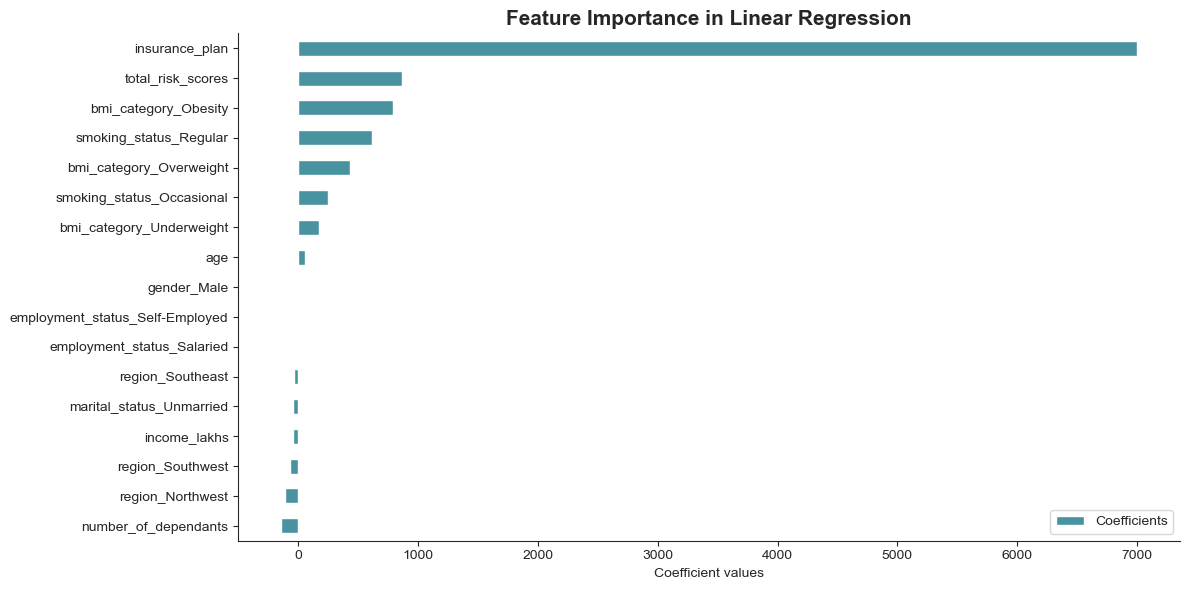

In [169]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in Linear Regression", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

Ridge Regression Model

In [170]:
model_rg = Ridge()
model_rg.fit(X_train, y_train)

Ridge()

In [171]:
y_pred = model_rg.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 3014582.254522132
RMSE: 1736.2552388753597
R2 Score: 0.6035869523841026


Lasso Regression Model

In [172]:
model_la = Lasso()
model_la.fit(X_train, y_train)

Lasso()

In [173]:
y_pred = model_la.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 3012380.366811578
RMSE: 1735.6210320261673
R2 Score: 0.6038764973174147


In [174]:
model_la.intercept_

6542.989601226886

In [175]:
model_la.coef_

array([ 4.84022005e+01, -1.04845824e+02, -1.28888500e+01,  6.98161660e+03,
        8.55901810e+02,  5.76875182e+00, -8.87987655e+01, -1.42695783e+01,
       -4.23225963e+01, -2.12439520e+00,  7.69758147e+02,  4.22901741e+02,
        1.58954751e+02,  2.30142446e+02,  6.11856211e+02, -6.61969015e+00,
       -0.00000000e+00])

In [176]:
feature_importance = model_la.coef_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
number_of_dependants,-104.845824
region_Northwest,-88.798766
region_Southwest,-42.322596
region_Southeast,-14.269578
income_lakhs,-12.888850
employment_status_Salaried,-6.619690
marital_status_Unmarried,-2.124395
employment_status_Self-Employed,-0.000000
gender_Male,5.768752
age,48.402201


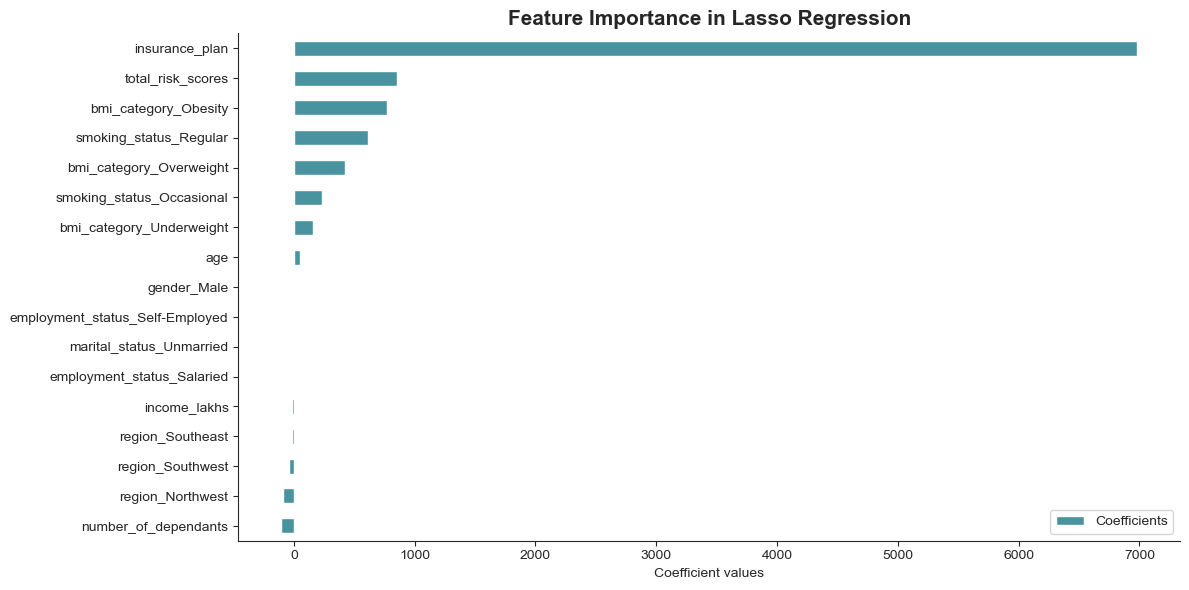

In [177]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in Lasso Regression", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

XGBoost : XGBRegressor Model

In [178]:
model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [179]:
y_pred = model_xgb.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 3338283.8712068223
RMSE: 1827.0971159757278
R2 Score: 0.5610206750182486


#### Hyparameter Tuning: XGBRegressor

1. Randomizedsearch CV

In [180]:
#use randomizedsearch cv
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}

rscv = RandomizedSearchCV(estimator= model_xgb, param_distributions= param_grid, n_iter= 10, cv= kfold, scoring='r2')
rscv.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=Non...
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [20, 40, 50]},
                   scoring='r2')

In [181]:
#print the best parameters and best scores
print(f"Best parameters: {rscv.best_params_}")
print(f"Best Score: {rscv.best_score_}")

#best model according to randomsearch cv
best_model = rscv.best_estimator_

Best parameters: {'n_estimators': 20, 'max_depth': 3, 'learning_rate': 0.2}
Best Score: 0.5974142564467975


#### Model Selection

In [182]:
best_model = model_lr

In [183]:
feature_importance = model_lr.coef_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
number_of_dependants,-143.073921
region_Northwest,-112.914961
region_Southwest,-65.199594
income_lakhs,-45.562179
marital_status_Unmarried,-40.733770
region_Southeast,-36.710445
employment_status_Salaried,-13.056971
employment_status_Self-Employed,-4.533553
gender_Male,9.146189
age,57.678970


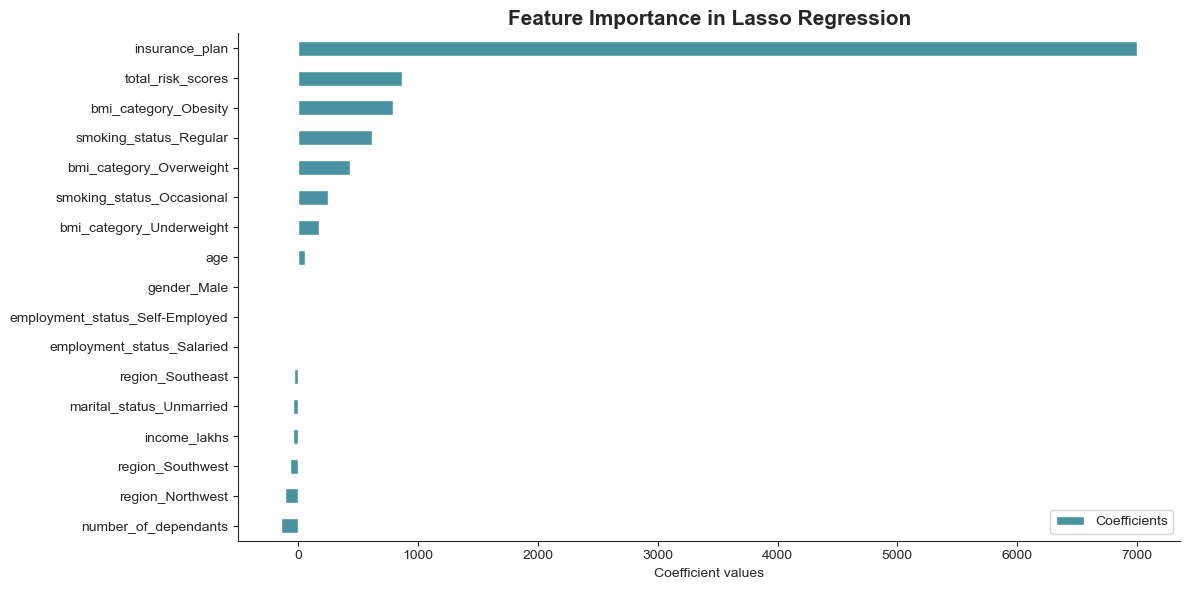

In [184]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in Lasso Regression", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

##### R2 metric is not good enough to evaluate the model

#### ERROR ANALYSIS

In [185]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals * 100) / y_test

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residuals_pct
})

results_df

,actual,predicted,diff,diff_pct
12774,6238,6629.781493,391.781493,6.280563
14758,9462,7118.517858,-2343.482142,-24.767302
13205,5152,7053.295140,1901.295140,36.904021
14278,6988,7921.170952,933.170952,13.353906
19351,4917,6697.683204,1780.683204,36.214830
...,...,...,...,...
17652,7635,6569.567029,-1065.432971,-13.954590
5807,4845,7070.670785,2225.670785,45.937478
10298,13866,11065.639064,-2800.360936,-20.195882
13316,5255,6734.525626,1479.525626,28.154627


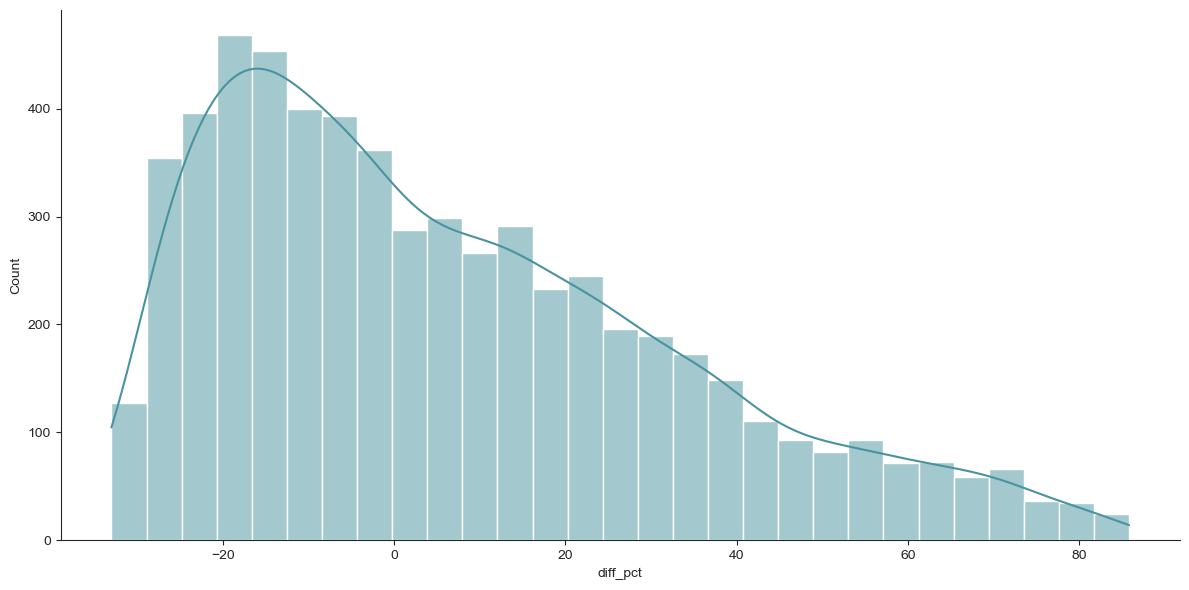

In [186]:
plt.figure(figsize=(12,6))
sns.histplot(results_df['diff_pct'], kde= True, color="#48939F")
sns.despine()
plt.tight_layout()
plt.show()

The distribution of diff_pct is sharply centered around 0%, indicating most predictions are close to the actual values, but it is right-skewed with a long positive tail, showing the model occasionally makes large over-predictions (and fewer extreme under-predictions).

In [187]:
# This dataframe isolates the predictions that are unacceptably inaccurate, based on a 10% error tolerance.
extreme_error_threshold = 10

extreme_result_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_result_df

,actual,predicted,diff,diff_pct
14758,9462,7118.517858,-2343.482142,-24.767302
13205,5152,7053.295140,1901.295140,36.904021
14278,6988,7921.170952,933.170952,13.353906
19351,4917,6697.683204,1780.683204,36.214830
10622,8947,7471.925790,-1475.074210,-16.486802
...,...,...,...,...
399,8673,7205.512956,-1467.487044,-16.920178
17652,7635,6569.567029,-1065.432971,-13.954590
5807,4845,7070.670785,2225.670785,45.937478
10298,13866,11065.639064,-2800.360936,-20.195882


In [188]:
extreme_error_pct = extreme_result_df.shape[0] * 100 / results_df.shape[0]
extreme_error_pct

73.13308994357783

About 73.13% of the predictions have errors larger than ±10%, indicating that the model shows limited reliability at this error tolerance level. We need to handle them.

In [189]:
results_df[np.abs(results_df['diff_pct']) > 50].sort_values(by='diff_pct', ascending= False)

,actual,predicted,diff,diff_pct
10288,3623,6731.910319,3108.910319,85.810387
16580,3538,6567.039681,3029.039681,85.614462
3652,3536,6559.646028,3023.646028,85.510351
17084,3562,6606.883335,3044.883335,85.482407
12285,3532,6522.609116,2990.609116,84.671832
...,...,...,...,...
1597,4653,6986.580857,2333.580857,50.152178
15966,4709,7068.570478,2359.570478,50.107676
4086,4592,6891.840414,2299.840414,50.083633
6596,4276,6415.677067,2139.677067,50.039220


<p>Approximately 525 customers are expected to be overcharged or undercharged by more than 50%</p>

##### Root cause of High margin error, ANALYSIS

In [190]:
X_test.index

Index([12774, 14758, 13205, 14278, 19351, 10622, 16391, 14799, 17184, 16348,
       ...
        8695,  9658, 14195,  1365,   399, 17652,  5807, 10298, 13316,  2583],
      dtype='int64', length=6026)

In [191]:
extreme_result_df.index

Index([14758, 13205, 14278, 19351, 10622, 14799, 16348,  5573,  5634, 14882,
       ...
       10266,  5484,  8988,  9658,  1365,   399, 17652,  5807, 10298, 13316],
      dtype='int64', length=4407)

In [192]:
extreme_error_df = X_test.loc[extreme_result_df.index]
extreme_error_df

,age,number_of_dependants,income_lakhs,insurance_plan,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
14758,0.285714,0.000000,0.060606,0.0,0.000,0,0,0,1,1,0,0,0,0,1,0,1
13205,0.714286,0.333333,0.141414,0.0,0.000,1,1,0,0,1,0,0,0,0,1,0,1
14278,0.714286,0.333333,0.222222,0.0,0.000,1,0,1,0,1,1,0,0,0,1,0,0
19351,0.571429,0.000000,0.101010,0.0,0.000,1,0,0,1,1,0,0,1,0,0,0,0
10622,0.428571,0.333333,0.050505,0.0,0.625,0,0,1,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,0.142857,0.666667,0.111111,0.0,0.750,0,0,0,1,1,0,0,1,0,0,1,0
17652,0.571429,0.000000,0.343434,0.0,0.000,1,0,0,0,1,0,0,0,0,0,1,0
5807,0.857143,0.333333,0.040404,0.0,0.000,1,1,0,0,1,0,0,0,0,1,0,0
10298,0.000000,0.000000,0.111111,0.5,0.000,1,0,1,0,1,0,1,0,0,1,1,0


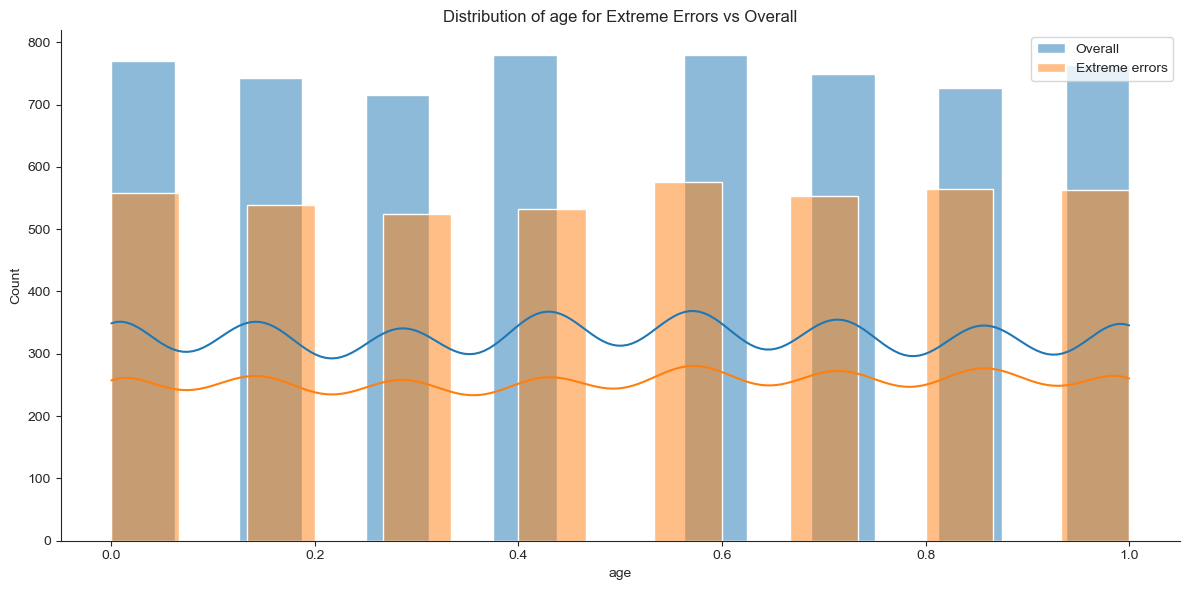

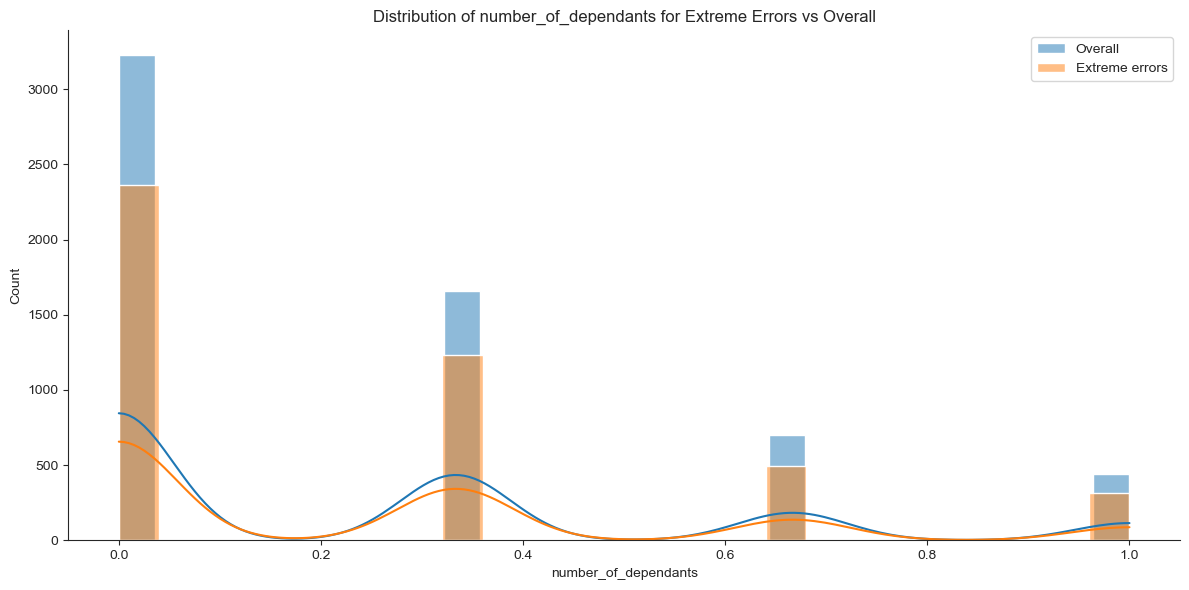

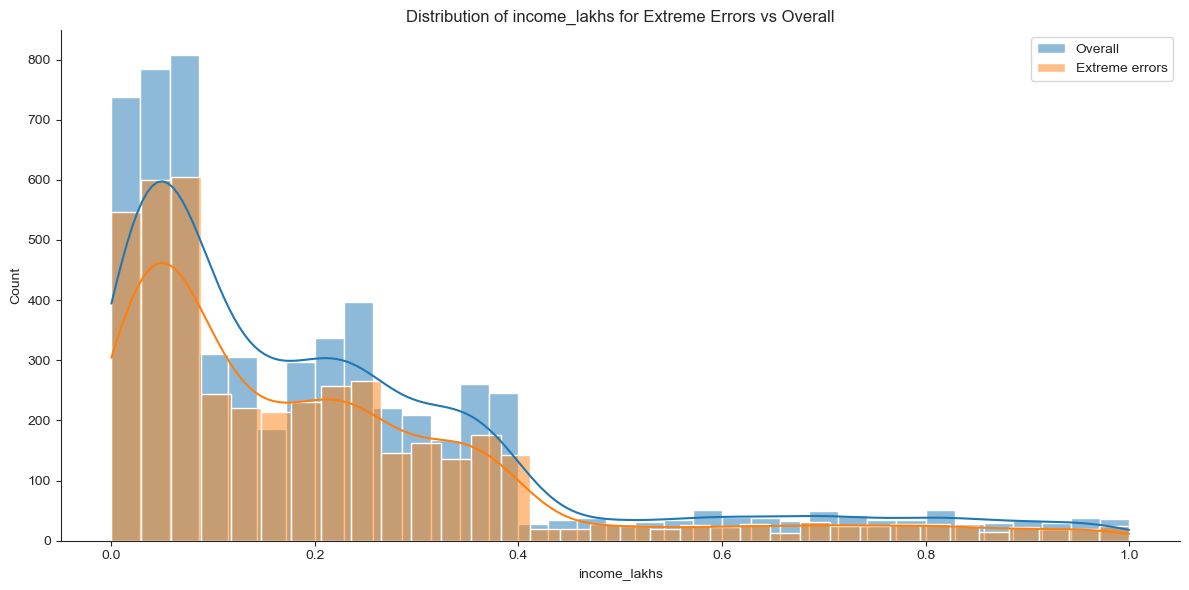

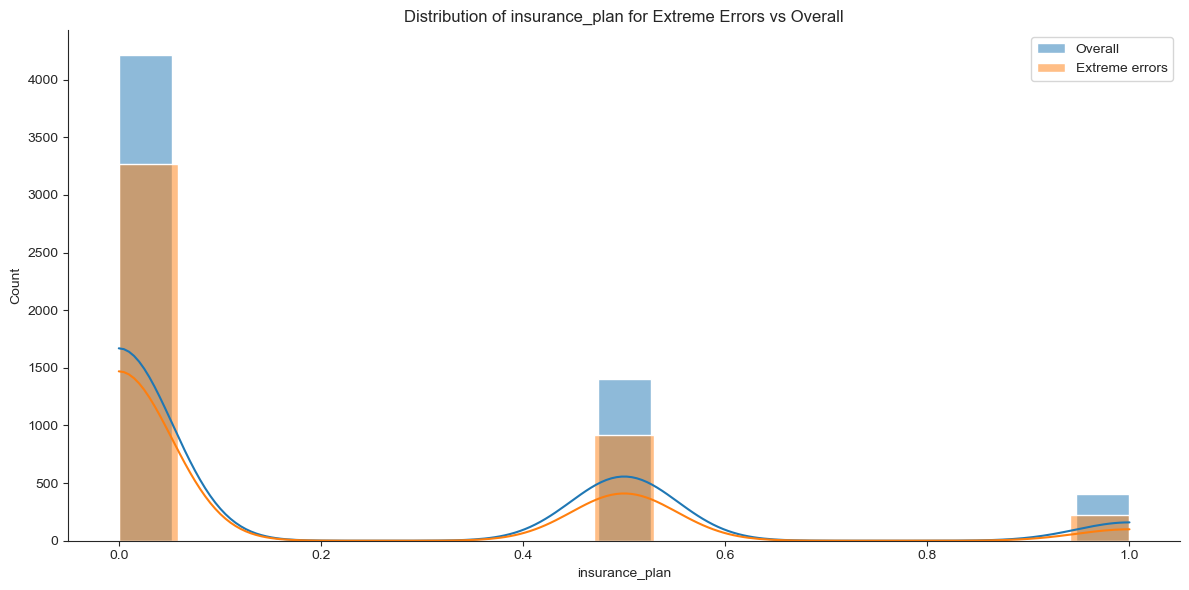

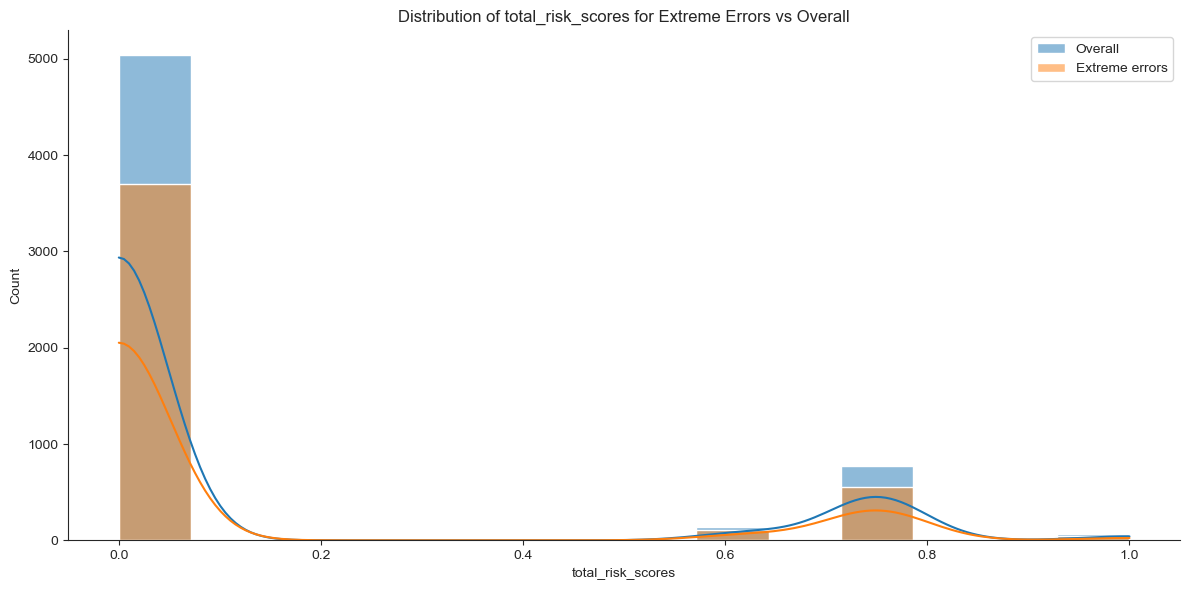

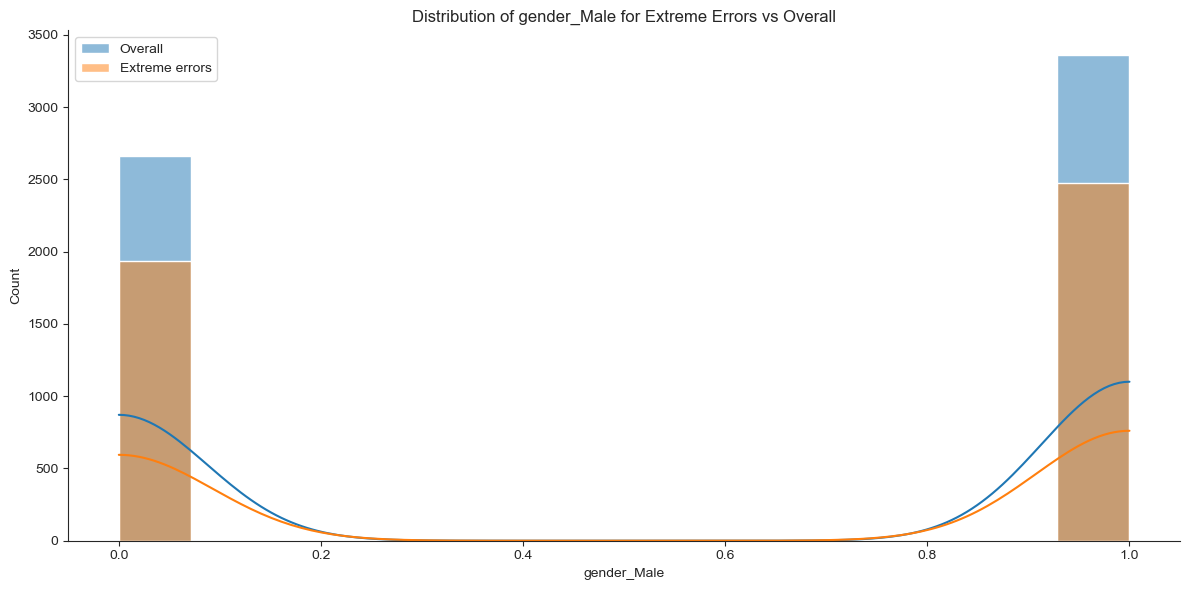

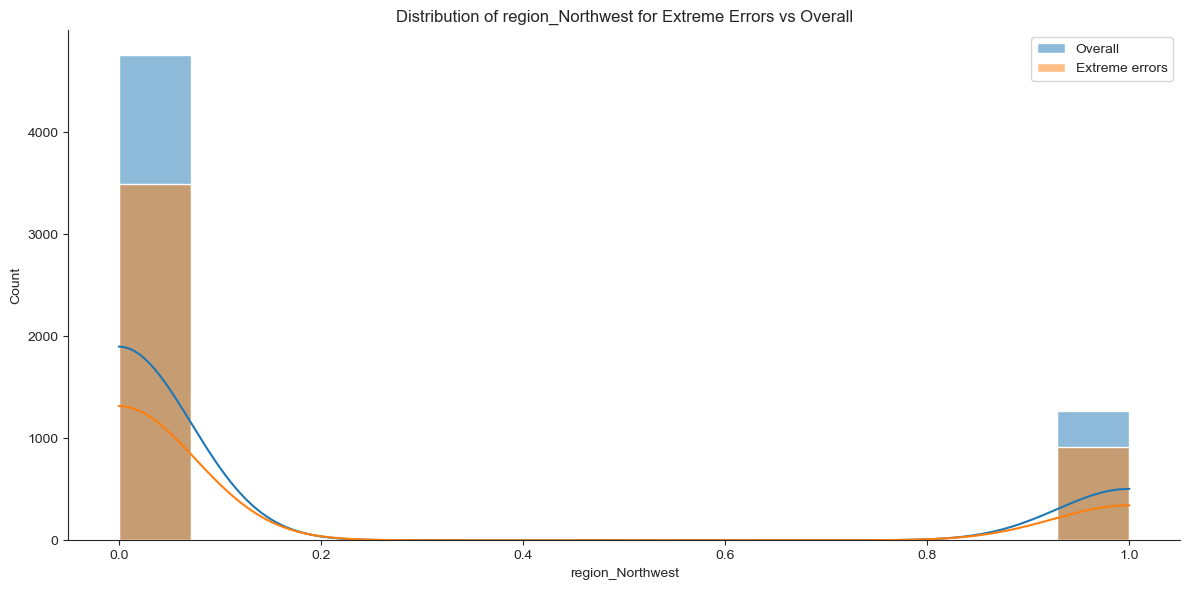

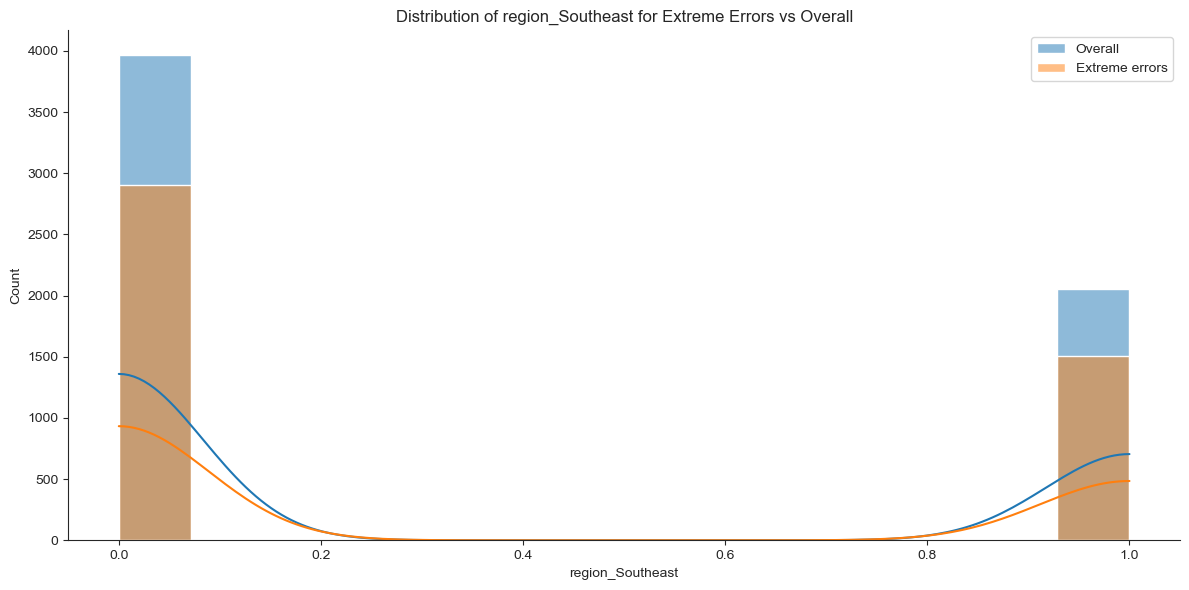

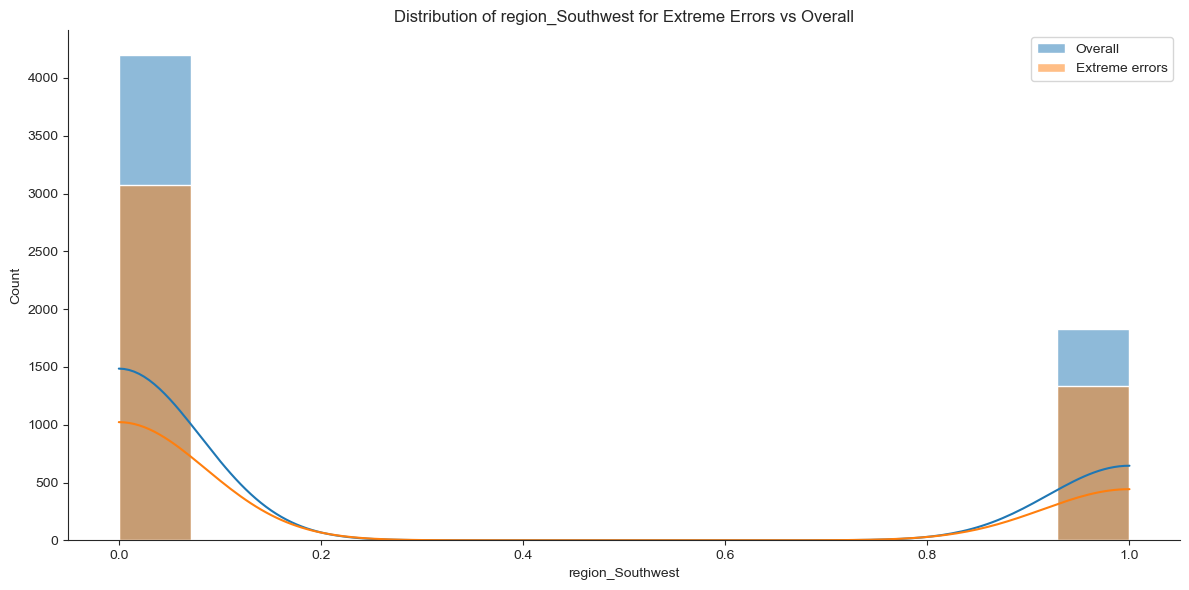

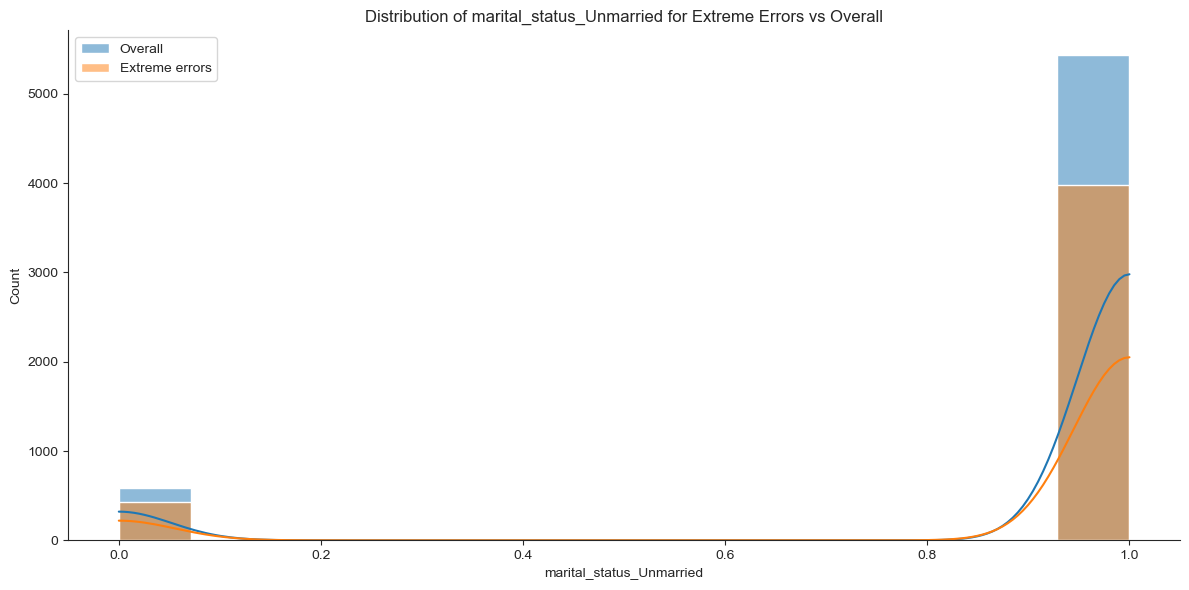

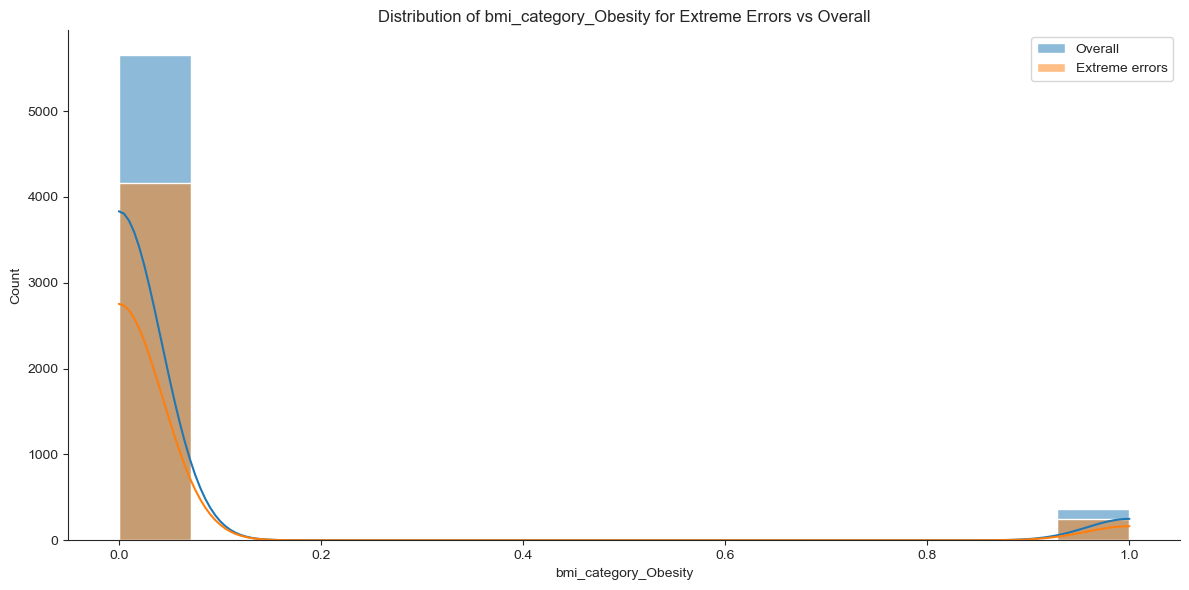

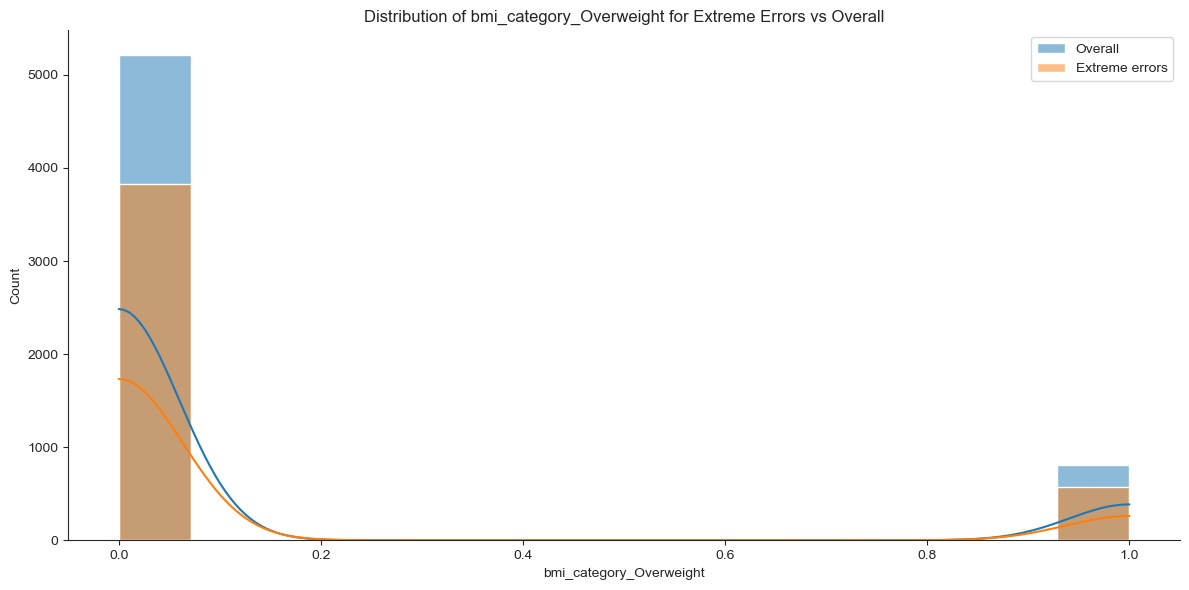

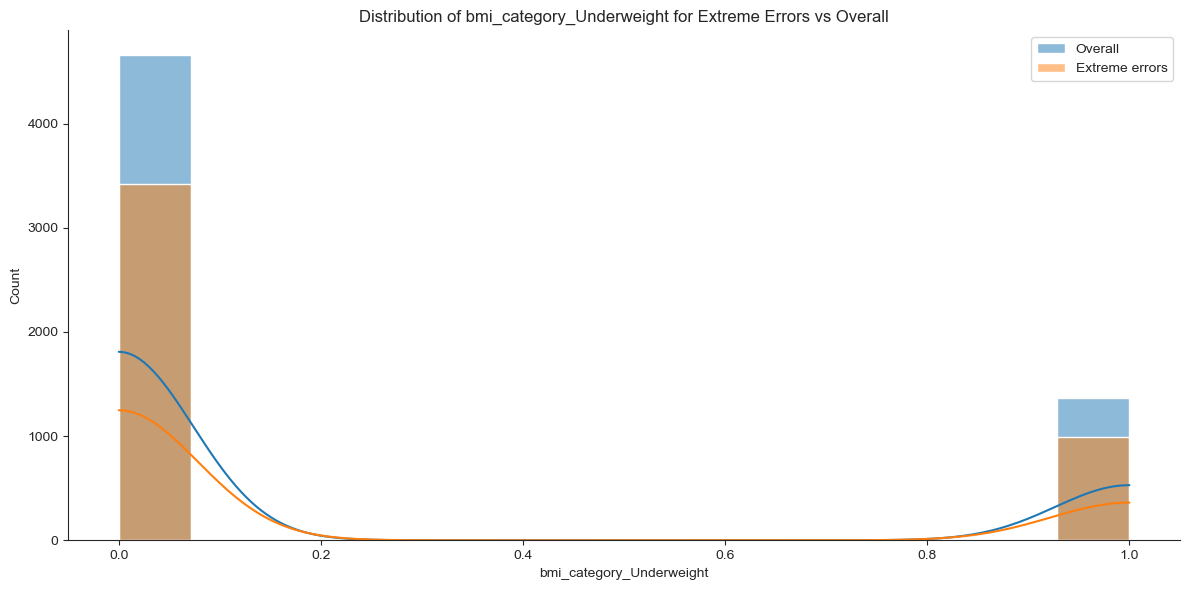

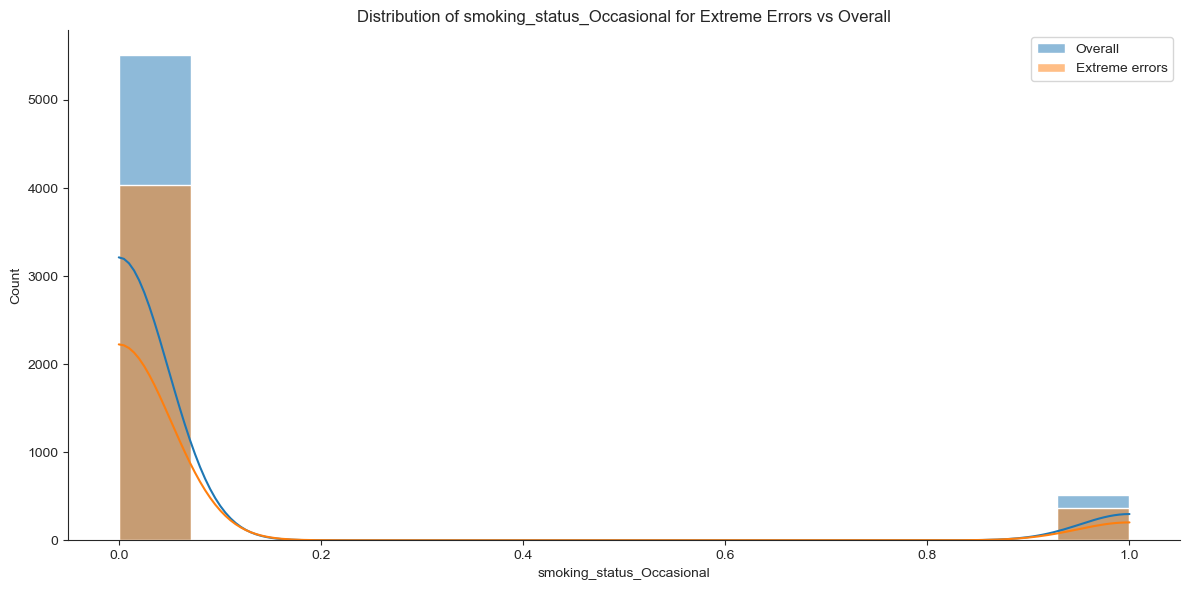

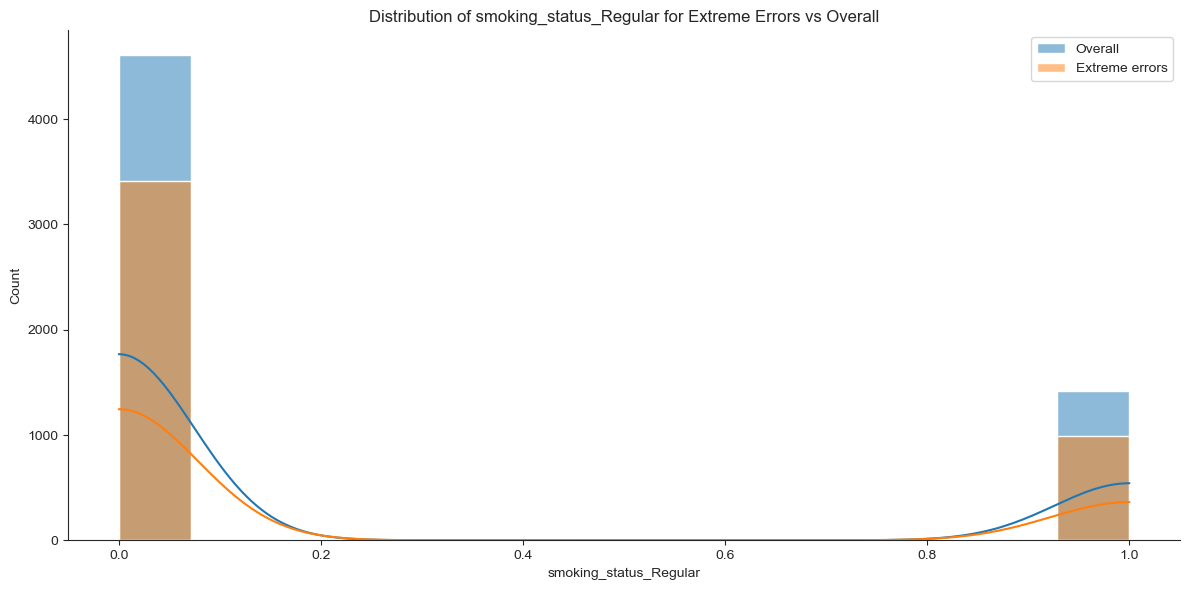

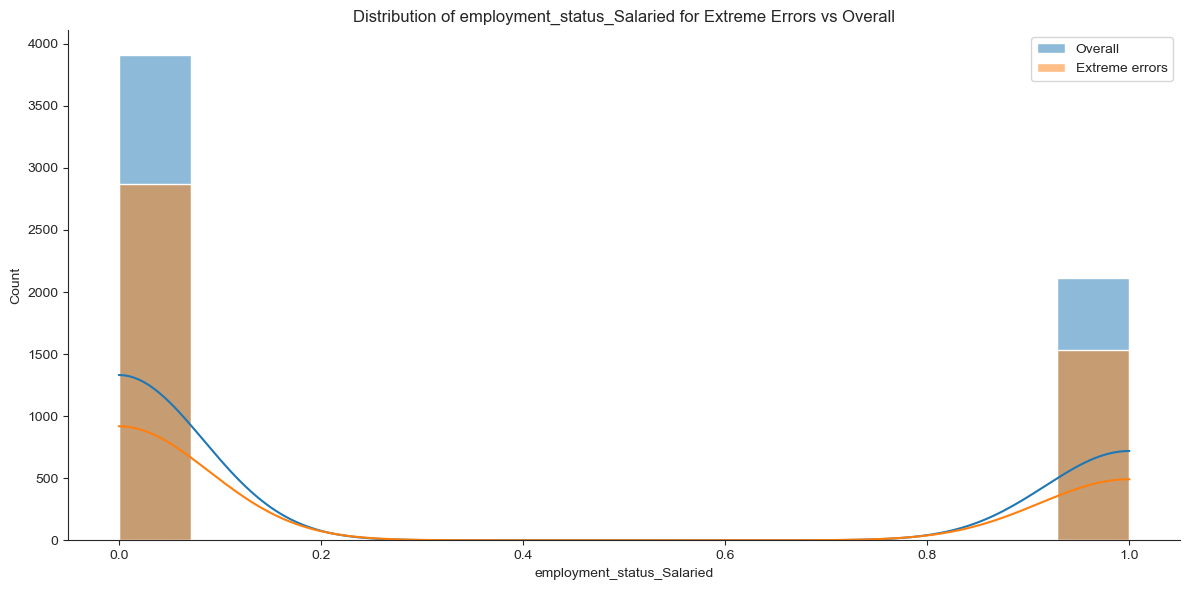

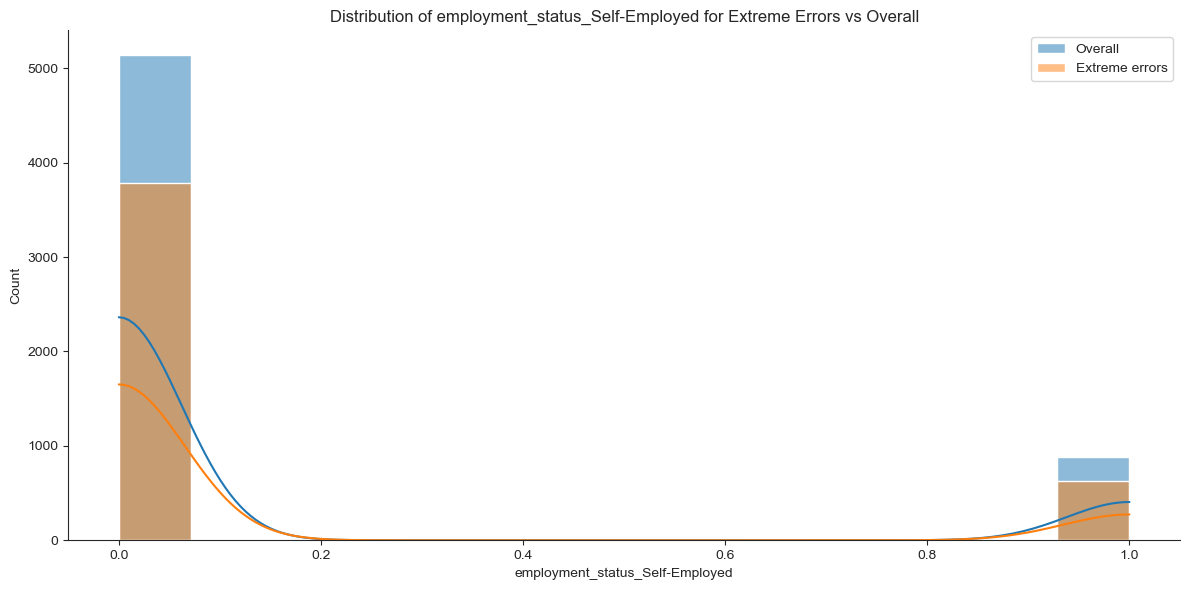

In [193]:
for feature in X_test.columns:
    plt.figure(figsize=(12,6))
    sns.set_style('ticks')
    sns.histplot(X_test[feature], kde=True, label = "Overall")
    sns.histplot(extreme_error_df[feature], kde= True, label = "Extreme errors")
    plt.title(f"Distribution of {feature} for Extreme Errors vs Overall")
    sns.despine()
    plt.tight_layout()
    plt.legend()
    plt.show()


By comparing distributions of results_df with extreme errors dataframe we don't get much insights. May be we need more features
in order to improve the performance. We will ask business to collect more features for our dataset as we are kind of stuck here